# MiniProject2: monthly commit activity

NetID: gwright30

Run from the extracted package folder. Source data and API snapshots are included in `sources/`. The original collection has 69,077 rows; 36 records recovered from GitHub are explicitly identified, and 32 remain missing. Read README_ANALYSIS.md for source scope, date rules, and limitations.

In [ ]:
from pathlib import Path
import os
import zipfile

# This notebook works directly from an extracted project folder.
# In Colab, upload a ZIP with sources/ and the project files, optionally inside one parent folder.
def find_project_folder(base):
    base = Path(base)
    options = [base, base / "gwright30_MP2"]
    options.extend(path.parent.parent for path in base.glob("*/sources/gwright30_project_summary.csv"))
    for folder in options:
        if (folder / "sources" / "gwright30_project_summary.csv").is_file():
            return folder
    return None

folder = find_project_folder(Path.cwd())
if folder is None:
    try:
        from google.colab import files
    except ImportError:
        raise RuntimeError("Run this notebook from the folder containing sources/, or upload a project ZIP in Google Colab.")
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if len(zip_names) != 1:
        raise RuntimeError("Upload exactly one ZIP containing the project files and sources/ folder.")
    destination = Path("/content/mp2_analysis")
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_names[0]) as archive:
        archive.extractall(destination)
    folder = find_project_folder(destination)
    if folder is None:
        raise RuntimeError("ZIP must contain sources/gwright30_project_summary.csv, at its root or inside one parent folder.")

os.chdir(folder)
print("Ready:", Path.cwd())


In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd()
SRC = ROOT / 'sources'
NETID = 'gwright30'
AS_OF = pd.Timestamp('2026-10-08T23:59:59Z')
COLS = ['project_wocid','commit_sha1','author','time','commit message']
raw = pd.read_csv(SRC/f'{NETID}_project_summary.csv',sep=';',keep_default_na=False)
missing_original = pd.read_csv(SRC/f'{NETID}_missing_commits.csv',sep=';')
assigned = pd.read_csv(SRC/f'{NETID}_assigned_projects.csv')
meta = json.loads((SRC/'github_current.json').read_text())
historical = json.loads((SRC/'github_historical_2025.json').read_text())
HISTORICAL_START = pd.Timestamp('2025-04-01T00:00:00Z')
HISTORICAL_END = pd.Timestamp('2025-09-30T23:59:59Z')
recovery = json.loads((SRC/'github_recovery.json').read_text())
interpretations = json.loads((SRC/'interpretations.json').read_text())
recovered = []
provenance = []
for item in recovery:
    response = item['result'].get('structuredContent',{})
    obj = json.loads(response['content']) if 'content' in response else {}
    if obj.get('sha') != item['sha']:
        continue
    for _, row in missing_original[missing_original.commit_sha1==item['sha']].iterrows():
        author = obj['author']
        recovered.append([row.project_wocid,item['sha'],f"{author['name']} <{author['email']}>",int(pd.Timestamp(author['date']).timestamp()),obj['message']])
        provenance.append({'project_wocid':row.project_wocid,'commit_sha1':item['sha'],'source':'GitHub git commit object','url':obj.get('url',''),'retrieved_on':'2026-10-08'})
df = pd.concat([raw,pd.DataFrame(recovered,columns=COLS)],ignore_index=True)
assert not df.duplicated(['project_wocid','commit_sha1']).any()
assert df.project_wocid.nunique()==10
assert df.commit_sha1.str.fullmatch('[0-9a-f]{40}').all()
df['time'] = pd.to_numeric(df.time,errors='raise').astype('int64')
df['date'] = pd.to_datetime(df.time,unit='s',utc=True)
assert df.date.max() <= AS_OF
df = df.sort_values(['project_wocid','time','commit_sha1'])
df[COLS].to_csv(ROOT/f'{NETID}_project_summary.csv',sep=';',index=False)
pd.DataFrame(provenance).to_csv(ROOT/f'{NETID}_recovered_commits.csv',sep=';',index=False)
unresolved = missing_original.merge(df[['project_wocid','commit_sha1']],how='left',on=['project_wocid','commit_sha1'],indicator=True)
unresolved = unresolved[unresolved._merge=='left_only'][['project_wocid','commit_sha1']]
unresolved.to_csv(ROOT/f'{NETID}_missing_commits.csv',sep=';',index=False)
statistics, gap_samples, recent_samples, observations, monthly_check, historical_evidence = [], [], [], [], [], []

def gap_runs(series):
    runs, current = [], []
    for month, count in series.items():
        if count == 0:
            current.append(month)
        elif current:
            runs.append(current)
            current = []
    if current:
        runs.append(current)
    return runs

for _, assignment in assigned.iterrows():
    project = assignment.WoC
    original_repo = assignment.GH.removeprefix('https://github.com/')
    info = json.loads(meta[original_repo][0]['content'])
    commits = json.loads(meta[original_repo][1]['content'])
    text = interpretations[project]
    group = df[df.project_wocid==project].copy()
    months = group.date.dt.tz_localize(None).dt.to_period('M')
    monthly = months.value_counts().reindex(pd.period_range(months.min(),months.max(),freq='M'),fill_value=0).sort_index()
    assert int(monthly.sum()) == len(group)
    runs = gap_runs(monthly)
    # max preserves the earliest run when multiple runs tie in length.
    longest = max(runs,key=len,default=[])
    start, end = (longest[0],longest[-1]) if longest else (None,None)
    timeseries = pd.DataFrame({'Month':monthly.index.astype(str),'#Commits':monthly.values})
    timeseries.to_csv(ROOT/f'{NETID}_commits_timeseries_{project}.csv',sep=';',index=False)
    fig, ax = plt.subplots(figsize=(11,4.8))
    ax.plot(monthly.index.to_timestamp(),monthly.values,lw=1.35,color='#225b8d')
    if longest:
        ax.axvspan(start.start_time,(end+1).start_time,color='#efb85c',alpha=.28,label=f'Longest gap: {len(longest)} months')
        ax.legend(frameon=False,loc='upper right')
    ax.set(title=project,xlabel='Month (YYYY-MM)',ylabel='Number of commits')
    locator = mdates.AutoDateLocator(minticks=5,maxticks=11)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x',rotation=40)
    ax.grid(alpha=.25)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    fig.savefig(ROOT/f'{NETID}_timeseries_{project}.png',dpi=300)
    plt.close(fig)
    pre = group[months<start].tail(10) if longest else group.iloc[:0]
    post = group[months>end].head(10) if longest else group.iloc[:0]
    for side,sample in [('pre',pre),('post',post)]:
        sample = sample[COLS].copy()
        sample.insert(0,'pre/post',side)
        gap_samples.append(sample)
    head = commits[0]
    last_date = pd.Timestamp(head['commit']['committer']['date'])
    # Determine the status *as of September 30, 2025*, rather than
    # comparing the October 2026 latest commit against an old cutoff.
    historical_commit = historical[original_repo]
    assert historical_commit['resolved_repository'].lower() == info['full_name'].lower()
    assert historical_commit['default_branch_checked'] == info['default_branch']
    hist_date = pd.Timestamp(historical_commit['latest_commit_committer_date_utc'])
    assert hist_date <= HISTORICAL_END
    hist_sha = historical_commit['latest_commit_sha_on_or_before_2025_09_30']
    assert len(hist_sha) == 40
    status = 'Active' if hist_date >= HISTORICAL_START else 'Inactive'
    today_status = 'Inactive' if last_date < pd.Timestamp('2026-04-08T00:00:00Z') else 'Active'
    for c in commits:
        recent_samples.append({'project_wocid':project,'commit_sha1':c['sha'],'author':c['commit']['author']['name'],'author_date':c['commit']['author']['date'],'committer_date':c['commit']['committer']['date'],'commit message':c['commit']['message'],'url':c['html_url']})
    missing_n = int((unresolved.project_wocid==project).sum())
    row = {'Project':project,'ncommits':len(group),'nauthors':group.author.nunique(),'from':group.date.min().isoformat(),'to':group.date.max().isoformat(),'nstars':info['stargazers_count'],'nforks':info['forks_count'],'lastGHCommitDate':last_date.isoformat(),'LongestGapStart':str(start) if longest else 'N/A','LongestGapEnd':str(end) if longest else 'N/A','LongestGapLength':len(longest),'NumCommitsAfterLastGap':int((months>end).sum()) if longest else 0,'ActivityPattern':text['pattern'],'NumberOfGapsInTimeline':sum(len(r)>=3 for r in runs),'BeforeThemes':text['before'],'AfterThemes':text['after'],'HypothesizedGapReason':text['reason'],'HasRecovered':text['recovered'],'WhyRecovered':text['why'],'WhoRecovered':text['who'],'Currentstatus':status,'RecentThemes':text['recent'],'Notes':text['notes'],'MissingCommitCount':missing_n,'GitHubRecoveredCommitCount':sum(z['project_wocid']==project for z in provenance),'GitHubRepository':info['full_name'],'GitHubDefaultBranch':info['default_branch'],'GitHubObservedOn':'2026-10-08','StatusAsOf2026_10_08':today_status,'HistoricalLastCommitDateUTC':hist_date.isoformat(),'HistoricalLastCommitSHA':hist_sha,'HistoricalReferenceDate':'2025-09-30','HistoricalEvidenceURL':historical_commit['commit_url']}
    statistics.append(row)
    historical_evidence.append({'Project':project,'AssignedRepository':original_repo,
        'ResolvedGitHubRepository':info['full_name'],'DefaultBranch':info['default_branch'],
        'ReferenceDateUTC':'2025-09-30','WindowStartUTC':'2025-04-01',
        'LastCommitAtOrBeforeReferenceUTC':hist_date.isoformat(),
        'HistoricalCommitSHA':hist_sha,'Currentstatus':status,
        'CommitURL':historical_commit['commit_url'],
        'GitHubAPIQuery':historical_commit['api_request']})
    observations.append({'Project':project,'GitHubURL':info['html_url'],'DefaultBranch':info['default_branch'],'Stars':info['stargazers_count'],'Forks':info['forks_count'],'LatestDefaultBranchCommit':head['sha'],'LastCommitDateUTC':last_date.isoformat(),'Source':('GitHub page manually checked; API used for exact counts rounded in UI' if project in {'catboost_catboost', 'pydata_pandas-datareader'} else 'GitHub page manually checked; API snapshot retained for exact recorded values'),'ObservedOn':'2026-10-08'})
    monthly_check.append({'Project':project,'Rows':len(group),'MonthlySum':int(monthly.sum()),'Months':len(monthly),'ZeroMonths':int((monthly==0).sum()),'PreSample':len(pre),'PostSample':len(post),'RemainingMissing':missing_n})
    lines=[f'# {project}', '', '## Reflection', '', text['reflection'], '',
           '## Commit activity and evidence', '',
           f'**Analyzed records:** {len(group):,} commits, {group.author.nunique():,} distinct author strings ({group.date.min().date()} to {group.date.max().date()}).',
           f'**Activity pattern:** {text["pattern"]}. **Gaps of at least three months:** {row["NumberOfGapsInTimeline"]}.',
           f'**Longest gap:** {start} through {end} ({len(longest)} zero-commit months); {row["NumCommitsAfterLastGap"]:,} commits afterward.' if longest else '**Longest gap:** None; there is at least one commit in every observed month.',
           '']
    if longest:
        lines += [f'**My best explanation for the gap:** {text["reason"]}',
                  '', f'**Recovery:** {text["recovered"]}. {text["why"]}',
                  '', f'**Contributors after the gap:** {text["who"]}',
                  '', f'**Themes before the gap:** {text["before"].replace(":", ", ")}. **After:** {text["after"].replace(":", ", ")}.',
                  '', '## Boundary-commit evidence', '',
                  '| Sample | UTC date | Author | Commit | Message |', '|---|---|---|---|---|']
        for side,sample in [('Before',pre),('After',post)]:
            for _,r in sample.iterrows():
                message=r['commit message'].splitlines()[0] if r['commit message'] else '(empty message)'
                author=r.author.split('<')[0].strip().replace('|','/')
                lines.append(f'| {side} | {r.date.date()} | {author} | [{r.commit_sha1[:8]}](https://github.com/{info["full_name"]}/commit/{r.commit_sha1}) | {message.replace(chr(124),"/")} |')
    else:
        lines += ['No pre/post-gap themes or recovery comparison applies because there is no zero-commit month in the observed timeline.']
    lines += ['', '## GitHub status and recent activity','',f'The GitHub default branch I checked was `{info["default_branch"]}` of [{info["full_name"]}]({info["html_url"]}). Its latest commit is [{head["sha"][:8]}]({head["html_url"]}), dated {last_date.isoformat()}. For the September 30, 2025 reference date, the latest commit found on that branch by then was [{hist_sha[:8]}]({historical_commit['commit_url']}) (committer date {hist_date.isoformat()}). That makes its historical status **{status}** using the April 1–September 30, 2025 window. Separately, the most recent October 2026 observation gives **{today_status}** for the six months ending October 8, 2026. These are default-branch commit-history checks, not a claim about every branch or fork.', '',f'The recent-ten themes are **{text["recent"]}**. The complete messages and links are in `{NETID}_github_recent_commits.csv`.','', '## Limits and supporting sources','',f'{missing_n} listed commits remain unavailable for this project, so a missing record could affect a gap measurement.' if missing_n else 'No commits from the supplied retrieval list remain unresolved for this project.', 'Author counts represent recorded author strings, not necessarily distinct people. The WoC timeline and the GitHub default branch may cover different histories; author timestamps and merge dates can also differ.']
    lines += ['',*[f'- {url}' for url in text['sources']], '']
    (ROOT/f'{NETID}_reflection_{project}.md').write_text('\n'.join(lines))

stats = pd.DataFrame(statistics)
stats.to_csv(ROOT/f'{NETID}_project_stats.csv',sep=';',index=False)
pd.concat(gap_samples,ignore_index=True).to_csv(ROOT/f'{NETID}_project_gap_commits.csv',sep=';',index=False)
pd.DataFrame(recent_samples).to_csv(ROOT/f'{NETID}_github_recent_commits.csv',sep=';',index=False)
pd.DataFrame(observations).to_csv(ROOT/f'{NETID}_github_observations.csv',sep=';',index=False)
pd.DataFrame(historical_evidence).to_csv(ROOT/f'{NETID}_github_historical_status.csv',sep=';',index=False)
pd.DataFrame(monthly_check).to_csv(ROOT/f'{NETID}_validation.csv',sep=';',index=False)
print(f'Original WoC rows: {len(raw):,}; recovered from GitHub: {len(recovered)}; analyzed: {len(df):,}; unresolved: {len(unresolved)}')
print(stats[['Project','ncommits','LongestGapLength','NumberOfGapsInTimeline','Currentstatus']].to_string(index=False))


Original WoC rows: 69,077; recovered from GitHub: 36; analyzed: 69,113; unresolved: 32
                    Project  ncommits  LongestGapLength  NumberOfGapsInTimeline Currentstatus
juliamanifolds_manifolds.jl      8262                 0                       0        Active
   pydata_pandas-datareader      1755                 7                       4        Active
         shellphish_driller       568                34                       7      Inactive
           threeme3_qcx-ssb       460                 9                       6        Active
humanbrainproject_fairgraph      1793                 3                       1        Active
     sancus-pma_sancus-core       459                18                      14        Active
              vcflib_vcflib      1763                 7                       3        Active
            mobleylab_blues      1658                30                       2      Inactive
   vinecopulib_rvinecopulib      1230                 4            

# Interpretation

The descriptions below are based on the monthly commit plots and the evidence saved with this project. I used complete months with zero recorded commits to measure gaps, but that doesn't tell me by itself why development stopped. Author timestamps, incomplete records, and GitHub branch differences also affect what I can conclude.


## catboost_catboost

**Overall pattern:** irregular. **Gaps of at least three months:** 0. **Longest gap:** None.

CatBoost never has a completely empty month in the data, although the number of commits changes a lot. There's a huge spike in 2023 and noticeably less activity in 2024, so I classified it as irregular rather than steady. Some messages refer to changes brought over from internal development, while others concern dependencies. That makes the graph useful for spotting activity changes, but I wouldn't treat every commit as the same amount of work. Since there isn't an inactivity gap, there isn't a before-and-after recovery to investigate.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_catboost_catboost.md`.


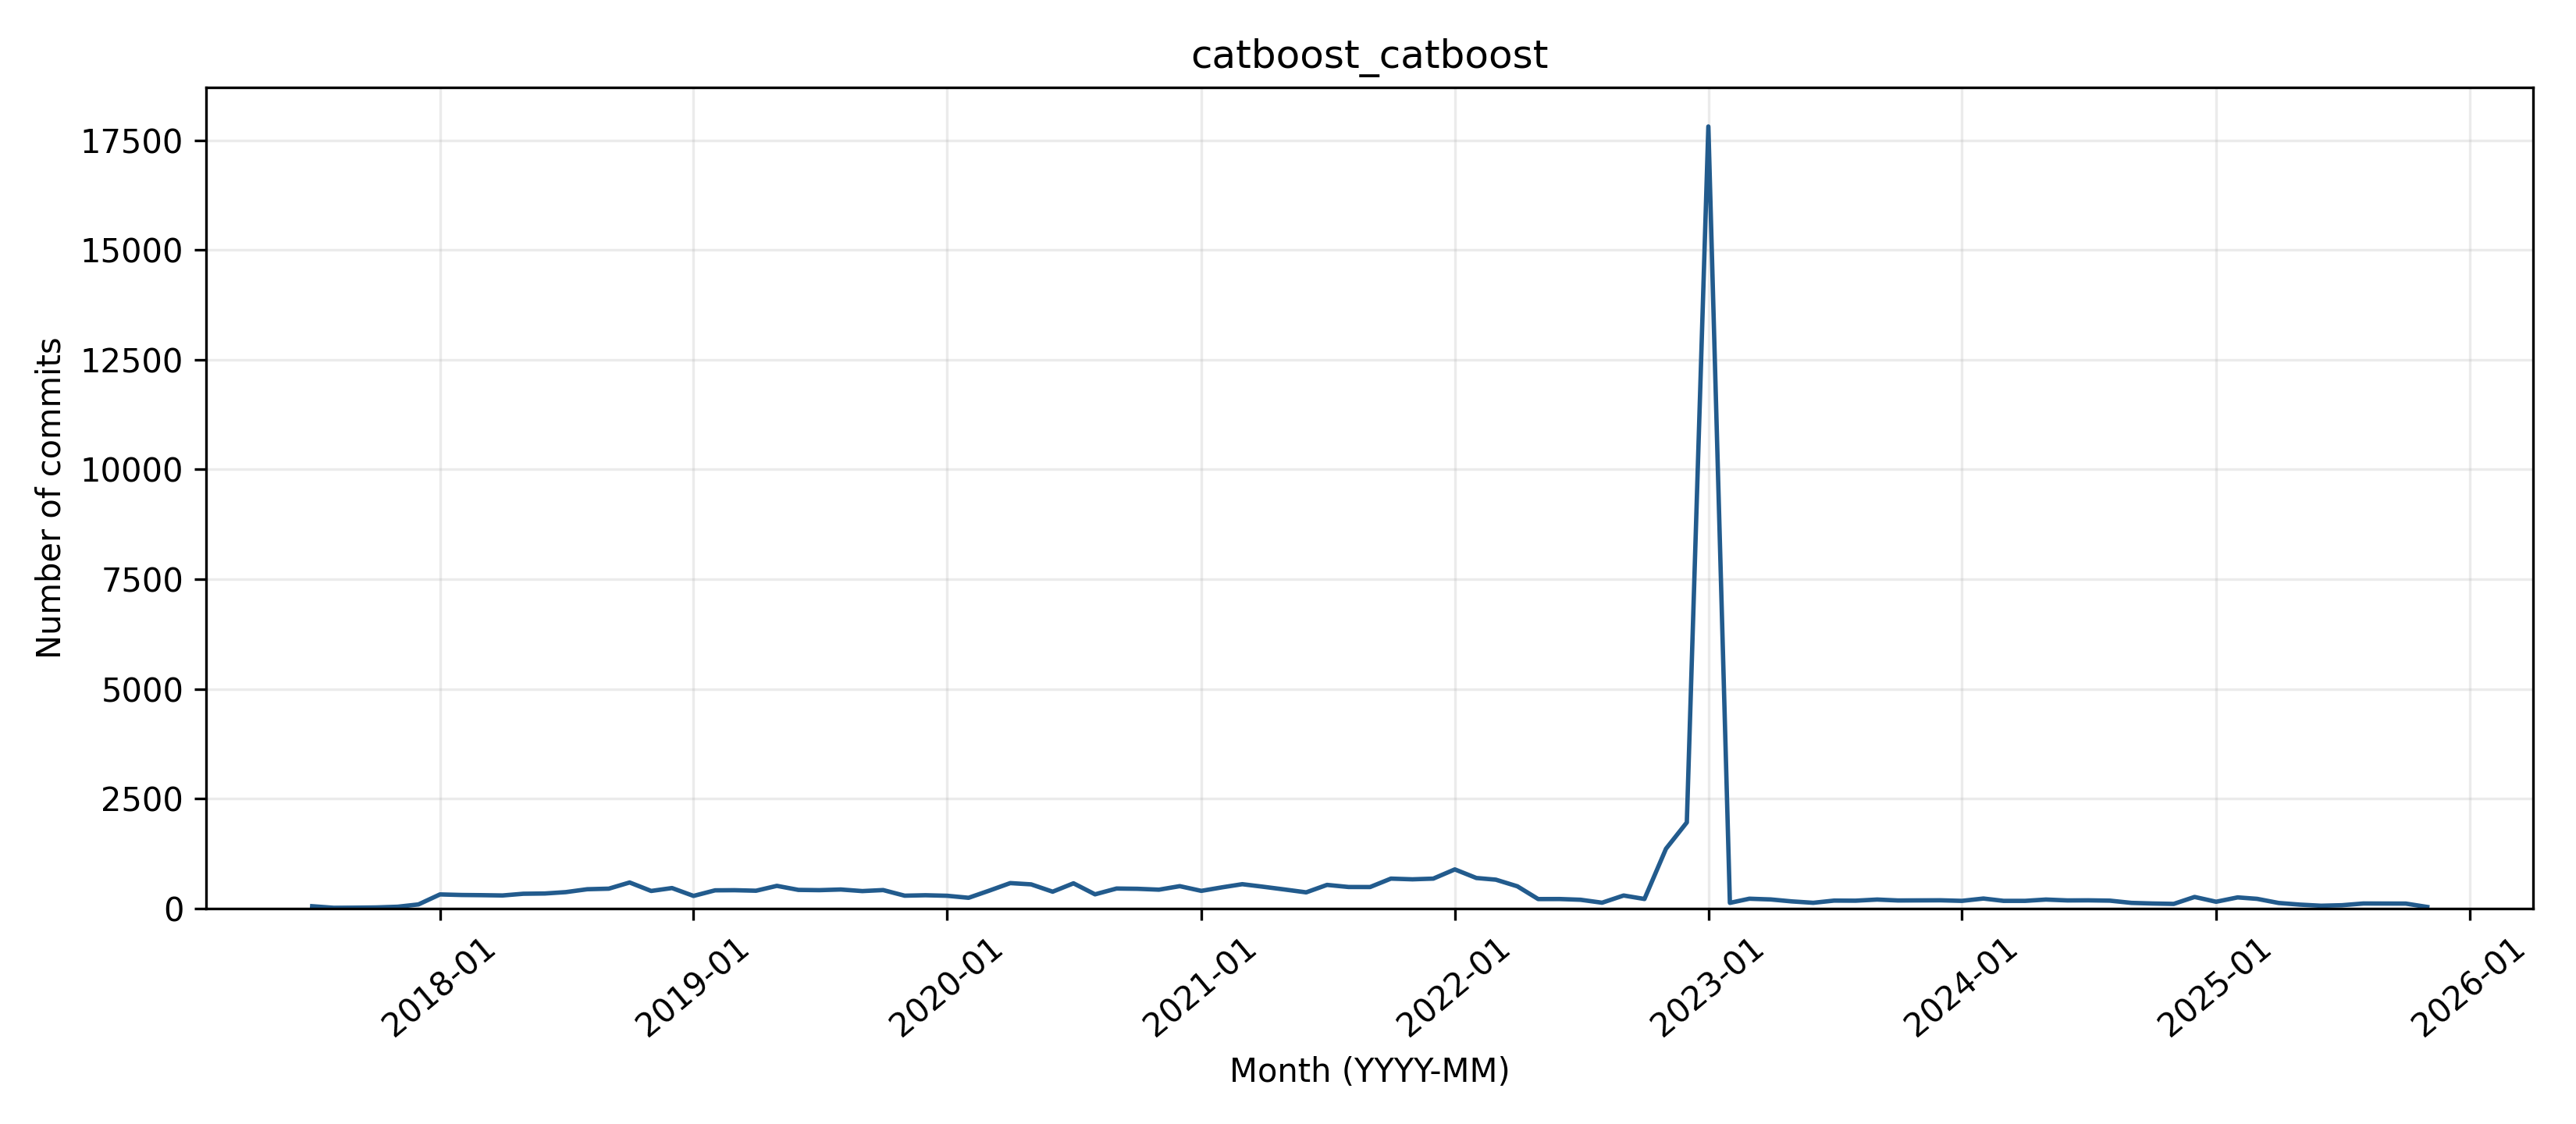

In [4]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_catboost_catboost.png", width=900))

## juliamanifolds_manifolds.jl

**Overall pattern:** declining. **Gaps of at least three months:** 0. **Longest gap:** None.

Manifolds.jl has commits in every observed month, so there is no inactivity gap to explain. The biggest burst of activity is in 2020, and later full years have fewer commits. I called that a declining pattern, but that doesn't mean the project was abandoned. Recent GitHub commits still include new functionality, fixes, and dependency work. I also wouldn't compare the incomplete 2026 year directly to a full year.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_juliamanifolds_manifolds.jl.md`.


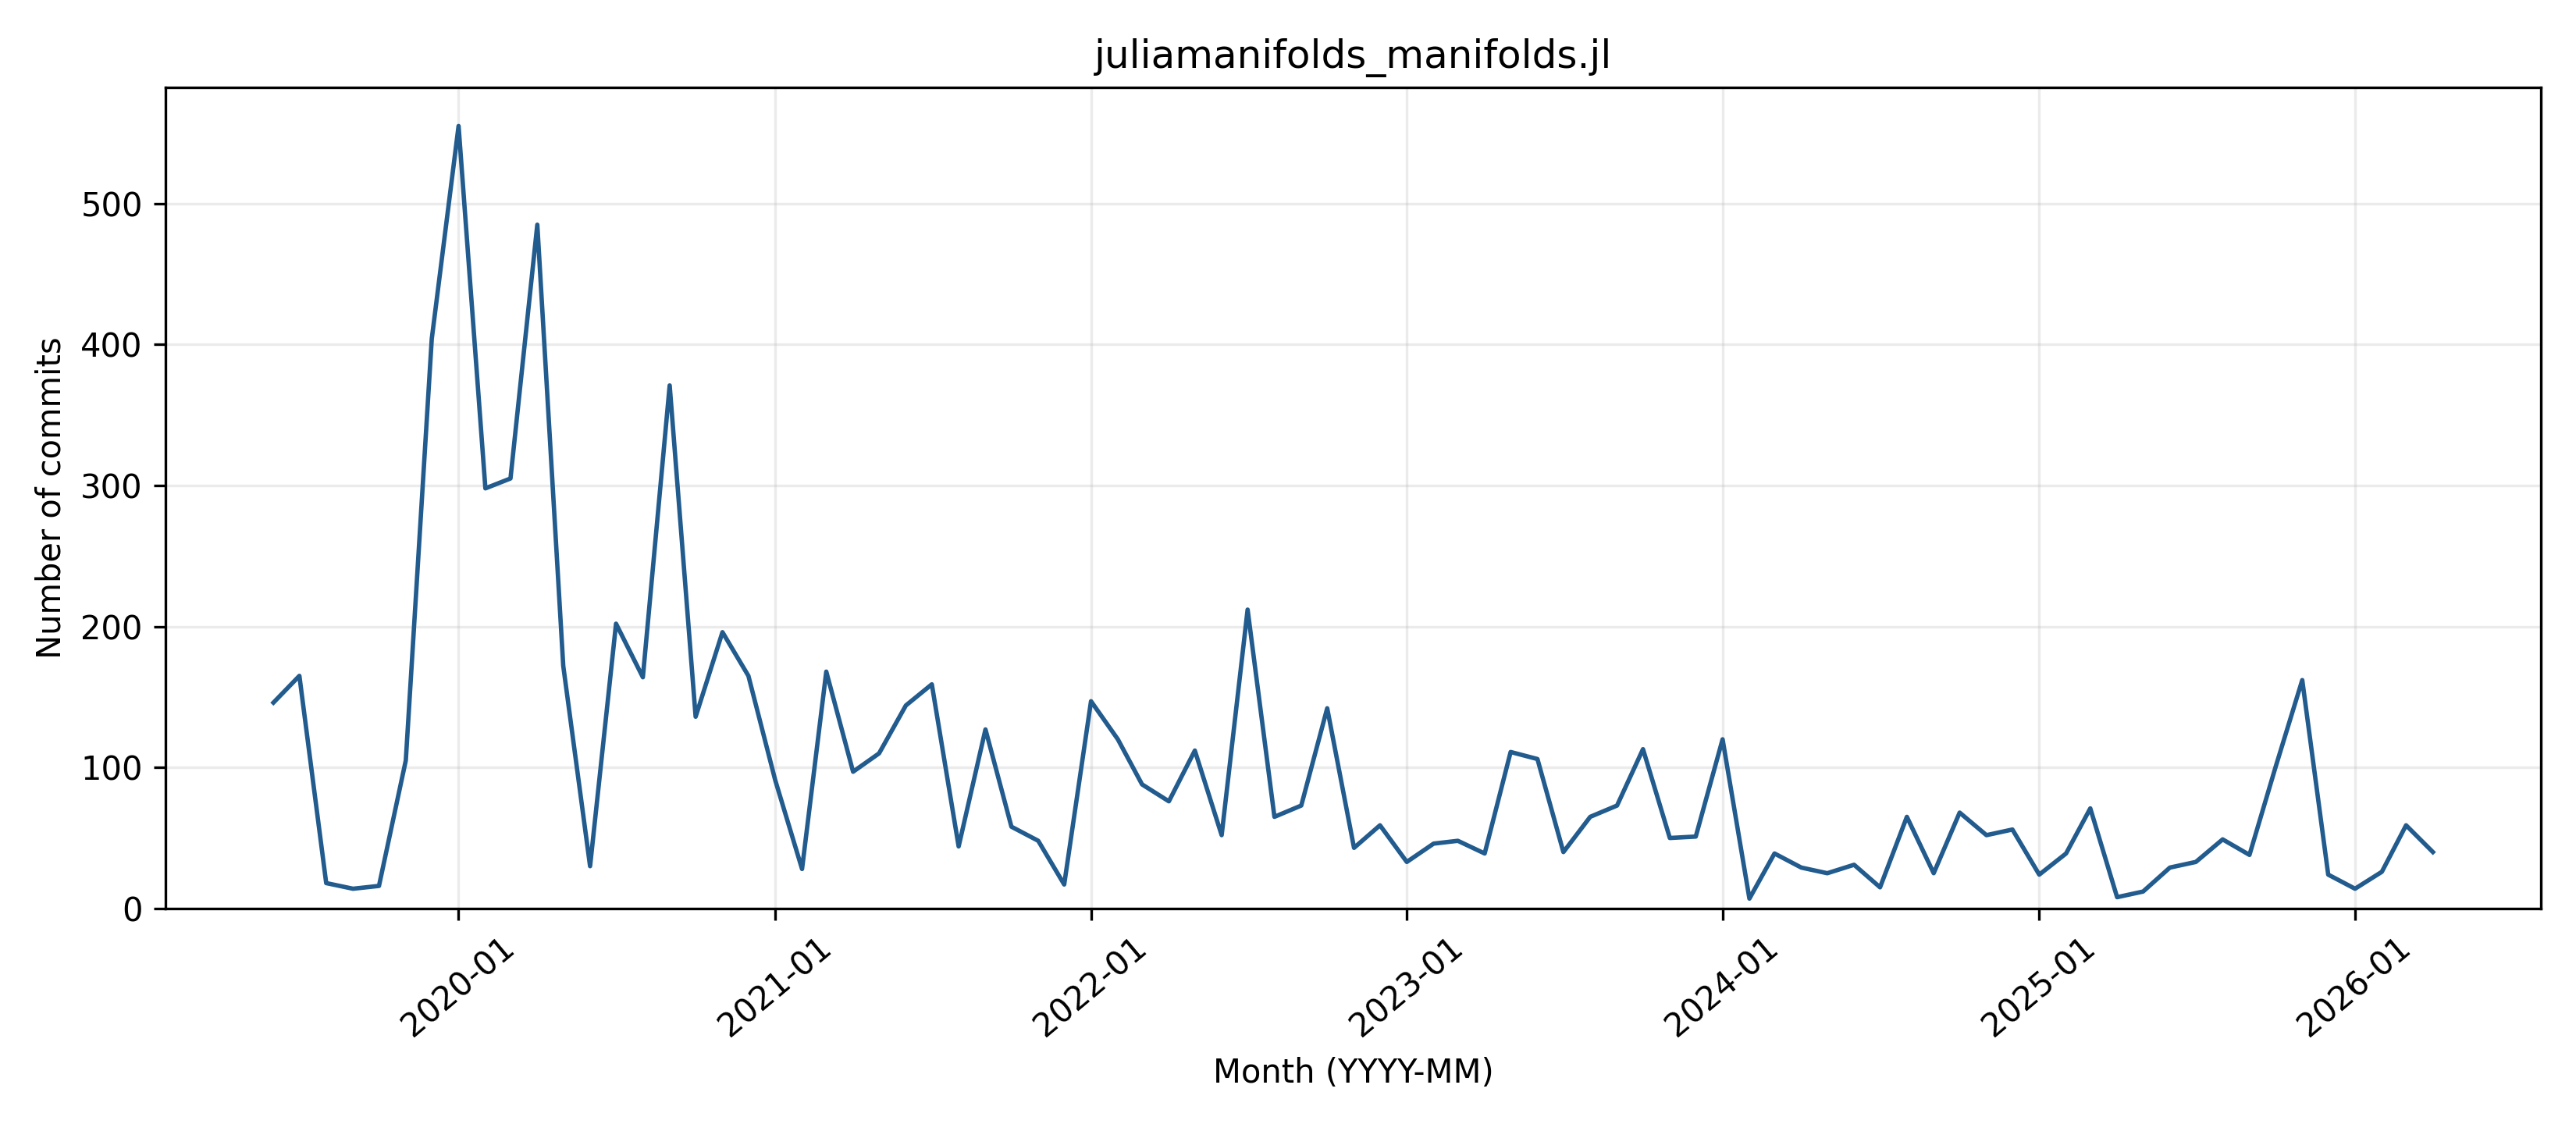

In [5]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_juliamanifolds_manifolds.jl.png", width=900))

## humanbrainproject_fairgraph

**Overall pattern:** declining. **Gaps of at least three months:** 1. **Longest gap:** 2018-06 through 2018-08 (3 months).

Fairgraph's longest gap is only three months, from June through August 2018. The last commit before it was the 0.1.0 release, and the first work afterward introduced a brain-simulation module. That makes a break between development stages seem possible, although nothing I found confirms why the contributors paused. Onur Ates handled the first post-gap commits, while Andrew Davison also contributed again afterward. Activity peaked later, around 2020, before settling to lower levels.

**Commit themes:** Before: Bug fixes:Feature development; after: Feature development:Bug fixes.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_humanbrainproject_fairgraph.md`.


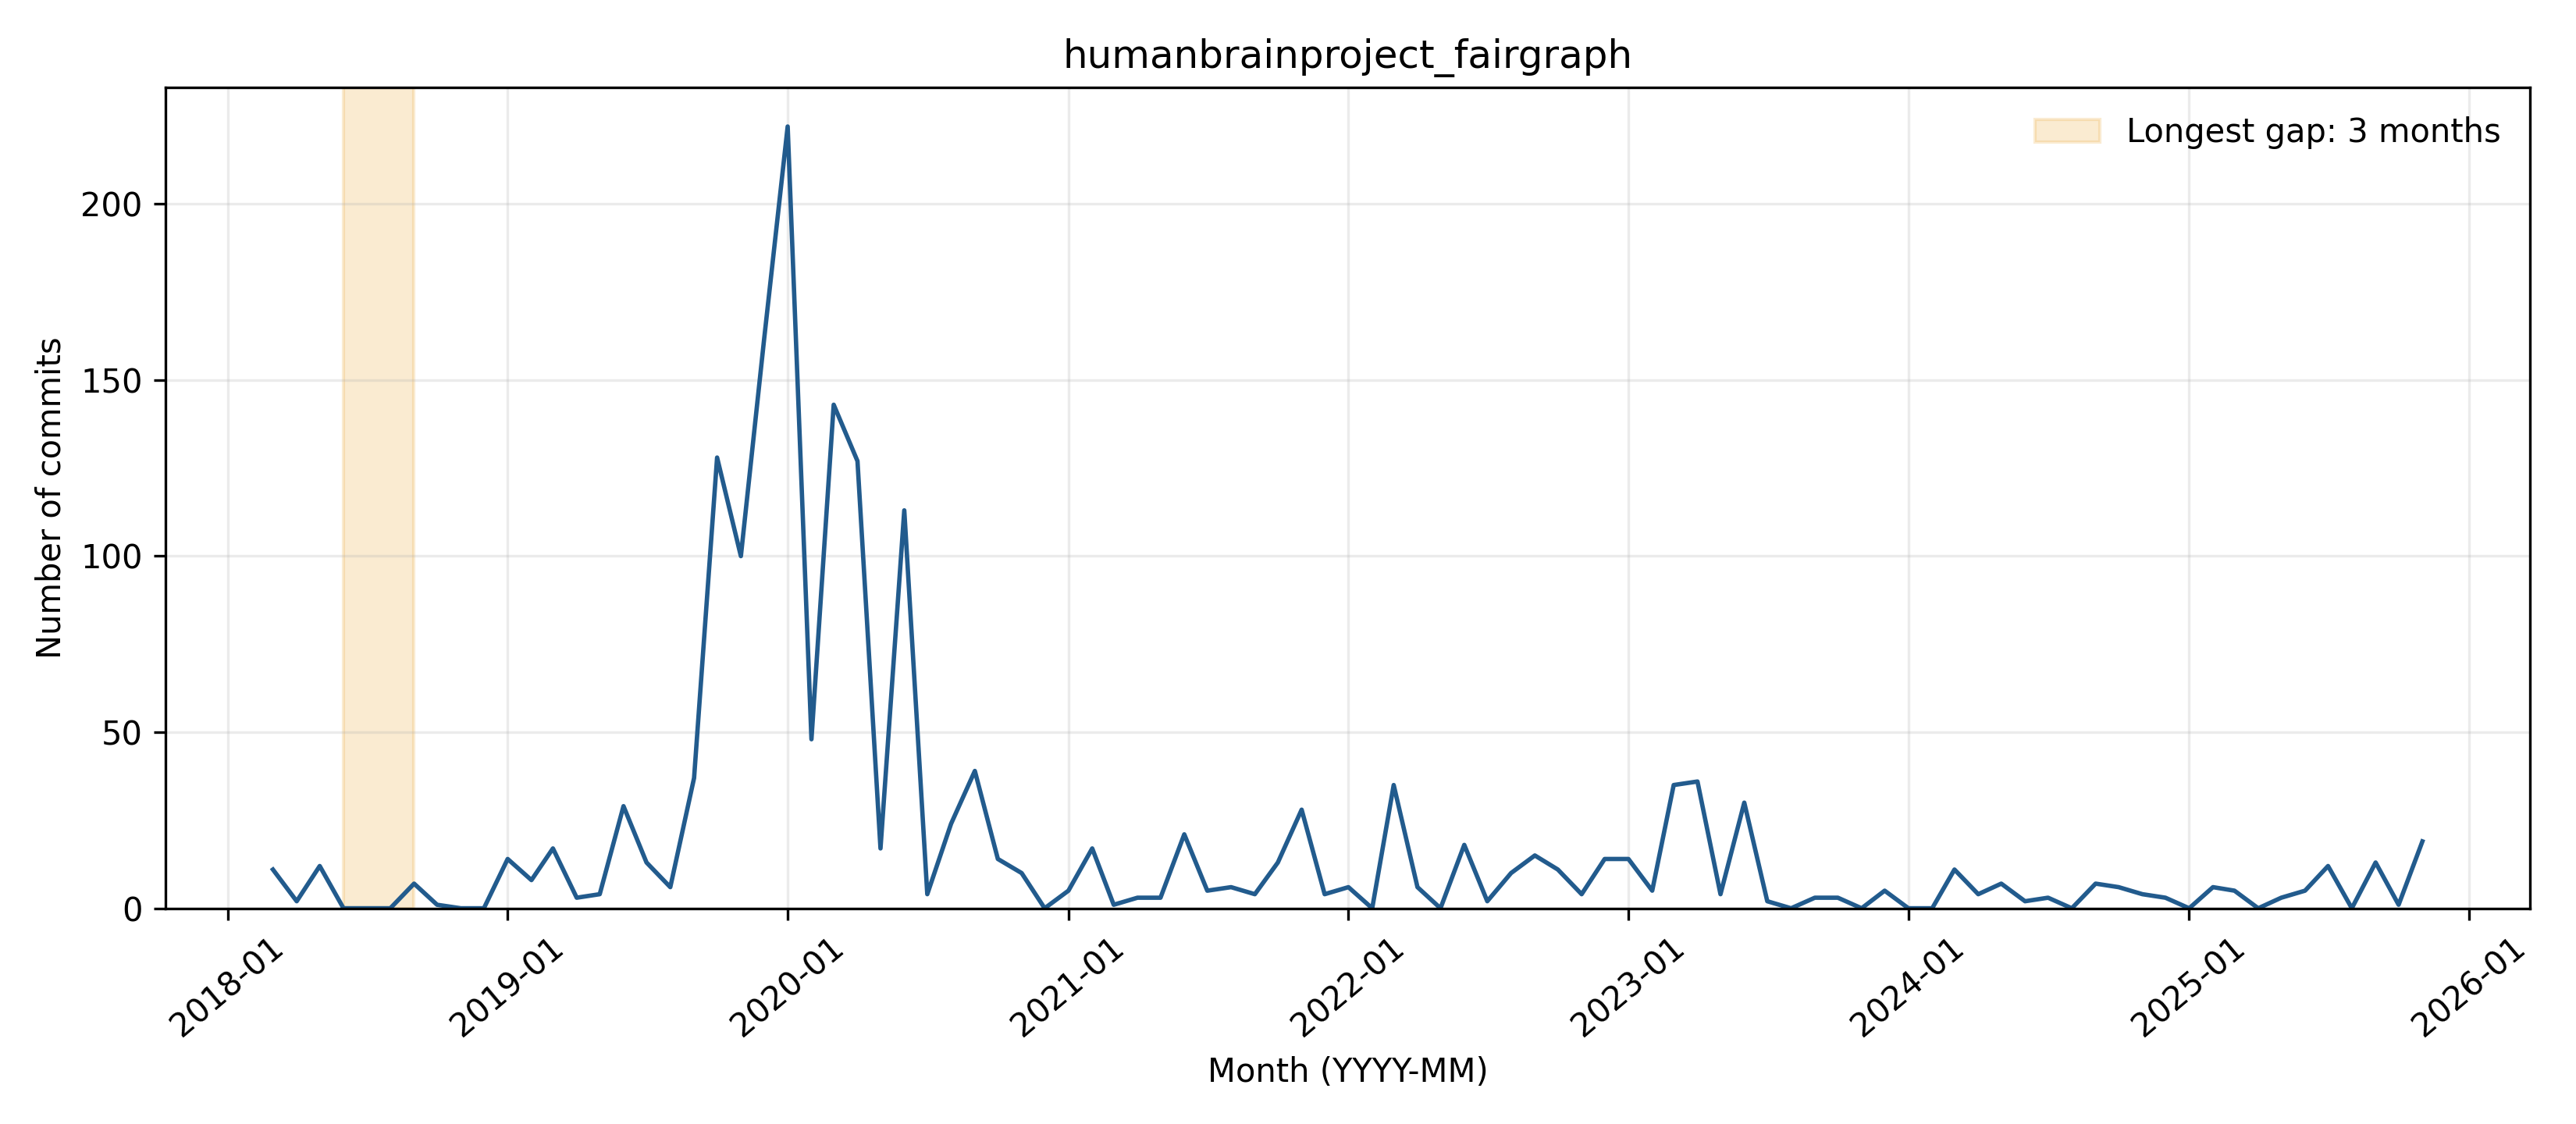

In [6]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_humanbrainproject_fairgraph.png", width=900))

## mobleylab_blues

**Overall pattern:** declining. **Gaps of at least three months:** 2. **Longest gap:** 2022-08 through 2025-01 (30 months).

BLUES was one of the harder projects to figure out because the WoC data and GitHub tell somewhat different stories. WoC shows a 30-month gap followed by commits in 2025, mostly dealing with outdated dependencies and testing. But the GitHub default branch hasn't changed since January 2021, and the 2022 pull request I checked wasn't merged. So while somebody was clearly working on compatibility fixes and testing, I wouldn't call that a full recovery of the main project. I also couldn't find anything that definitively explains why it went quiet.

**Commit themes:** Before: Documentation updates:Other; after: Dependency updates:Other.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_mobleylab_blues.md`.


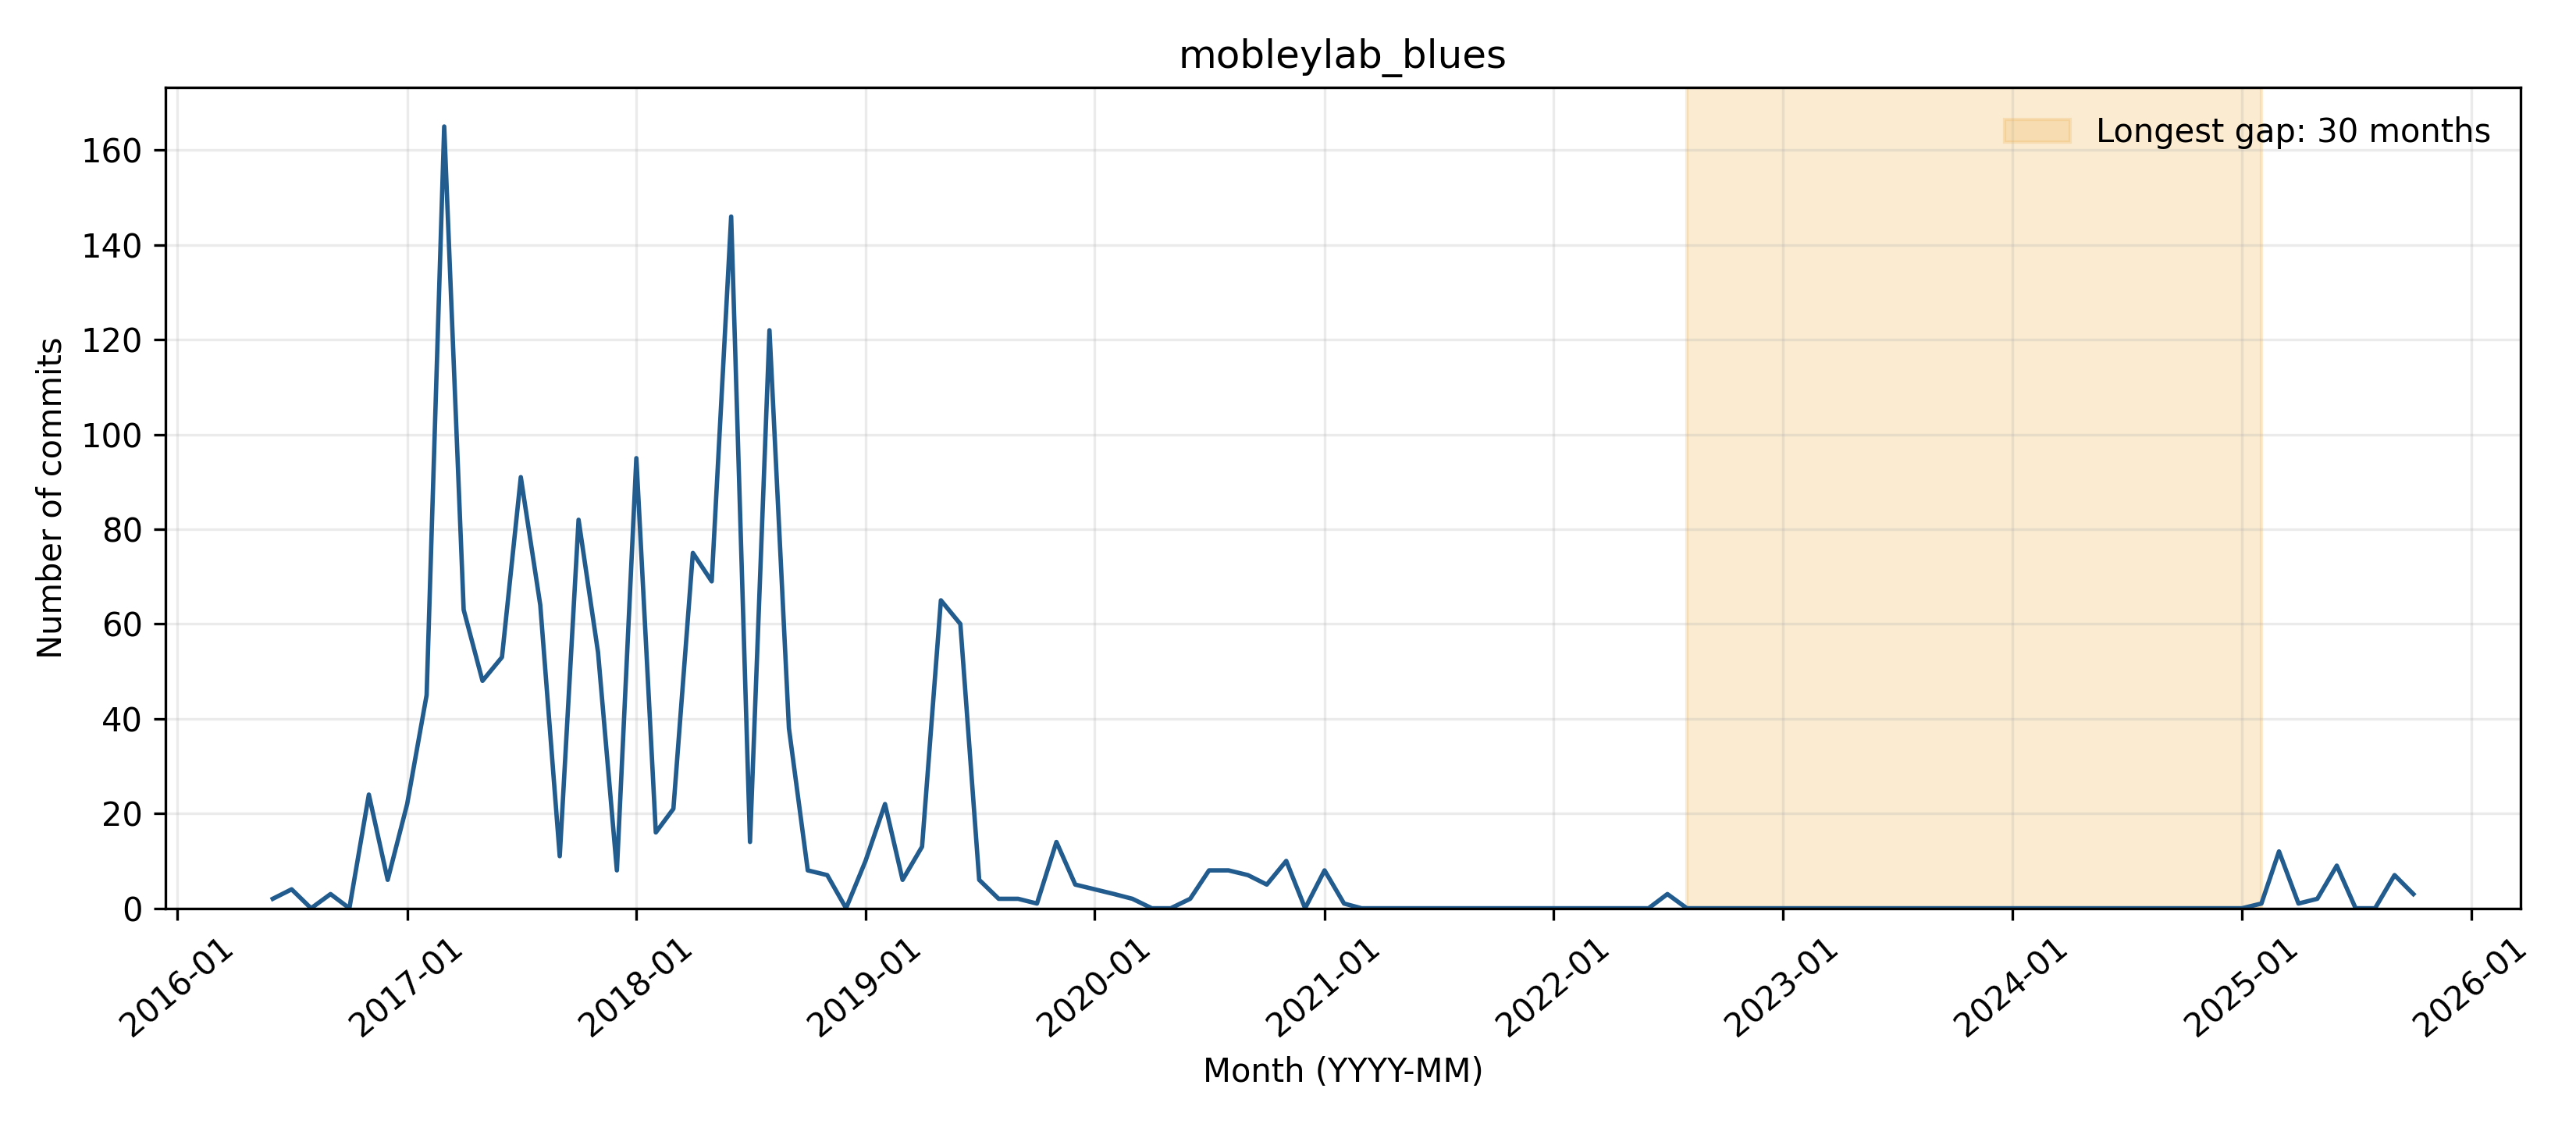

In [7]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_mobleylab_blues.png", width=900))

## pydata_pandas-datareader

**Overall pattern:** declining. **Gaps of at least three months:** 4. **Longest gap:** 2024-09 through 2025-03 (7 months).

pandas-datareader was already slowing down before its seven-month gap from September 2024 through March 2025. What happened afterward is easier to understand than why it stopped: the April 2025 messages specifically mention pandas 3 compatibility, followed by dependency, installation, and CI fixes. PR #1001 was merged, so at least some of that work made it into the GitHub project. Kevin Sheppard wrote the first ten commits after the gap. I couldn't find enough evidence to say why the project went quiet originally.

**Commit themes:** Before: Other:Bug fixes; after: Dependency updates:Bug fixes.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_pydata_pandas-datareader.md`.


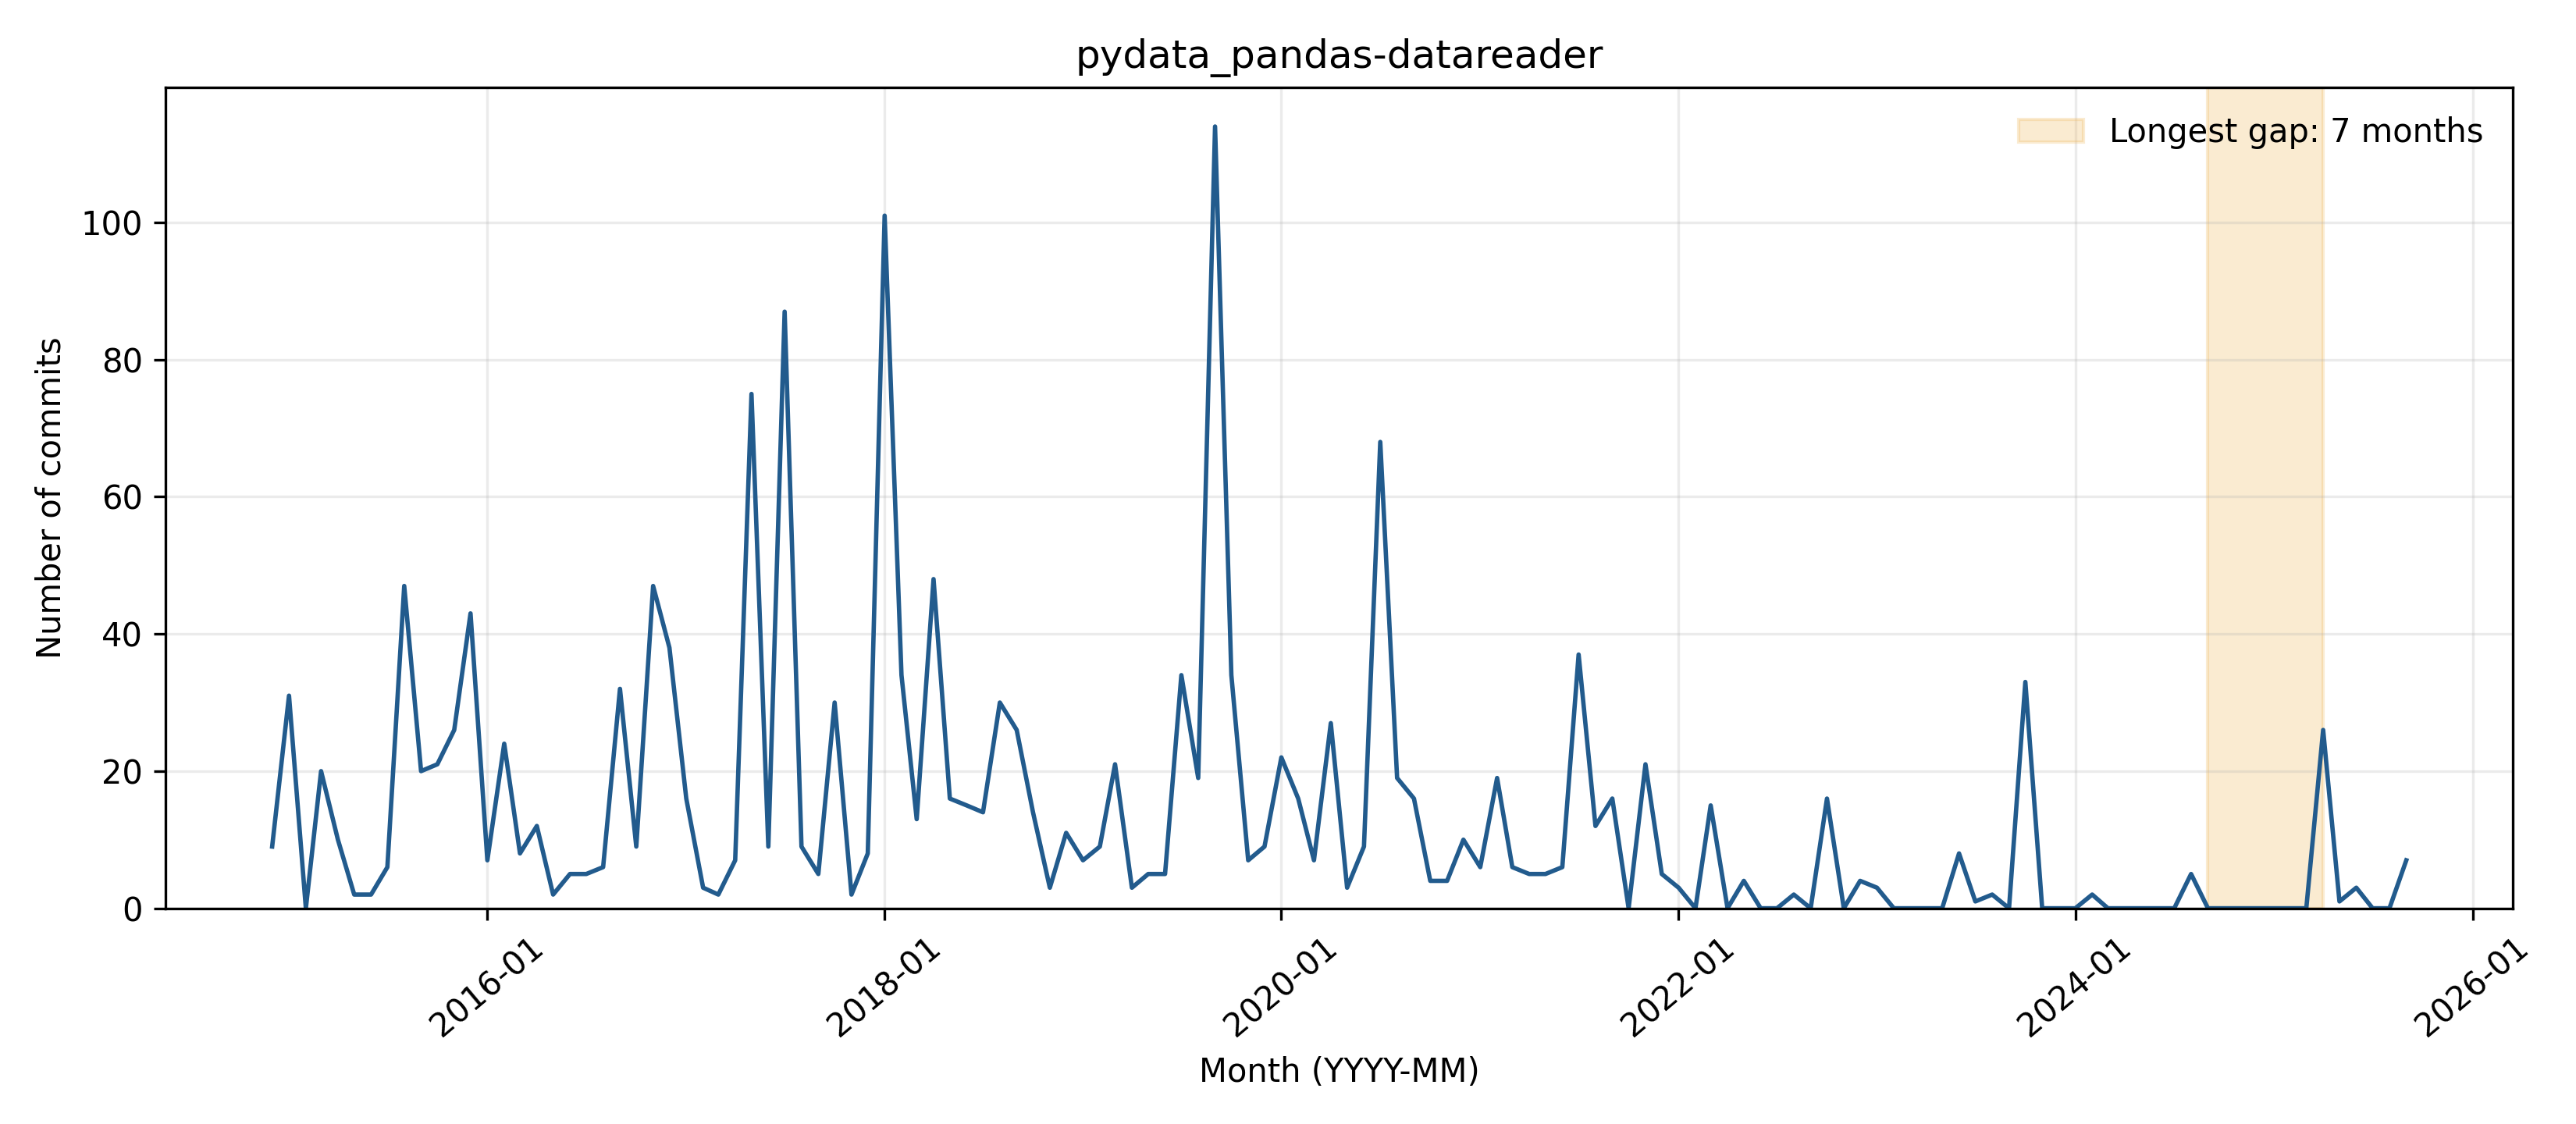

In [8]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_pydata_pandas-datareader.png", width=900))

## sancus-pma_sancus-core

**Overall pattern:** irregular. **Gaps of at least three months:** 14. **Longest gap:** 2023-06 through 2024-11 (18 months).

Sancus-core has a lot of stop-and-start activity: fourteen gaps of at least three months, including an 18-month gap from June 2023 through November 2024. Here the reason for the restart is unusually clear. The first post-gap work changes the cryptographic state machine to avoid a timing leak, and PR #33 links that work to the issue reported in #27. Ruben Van Dijck led the security fix, while Jo Van Bulck came back for CI work. But there are only six post-gap commits in the collected data, so I wouldn't call it a sustained revival.

**Commit themes:** Before: Other:Feature development; after: Security patches:Other.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_sancus-pma_sancus-core.md`.


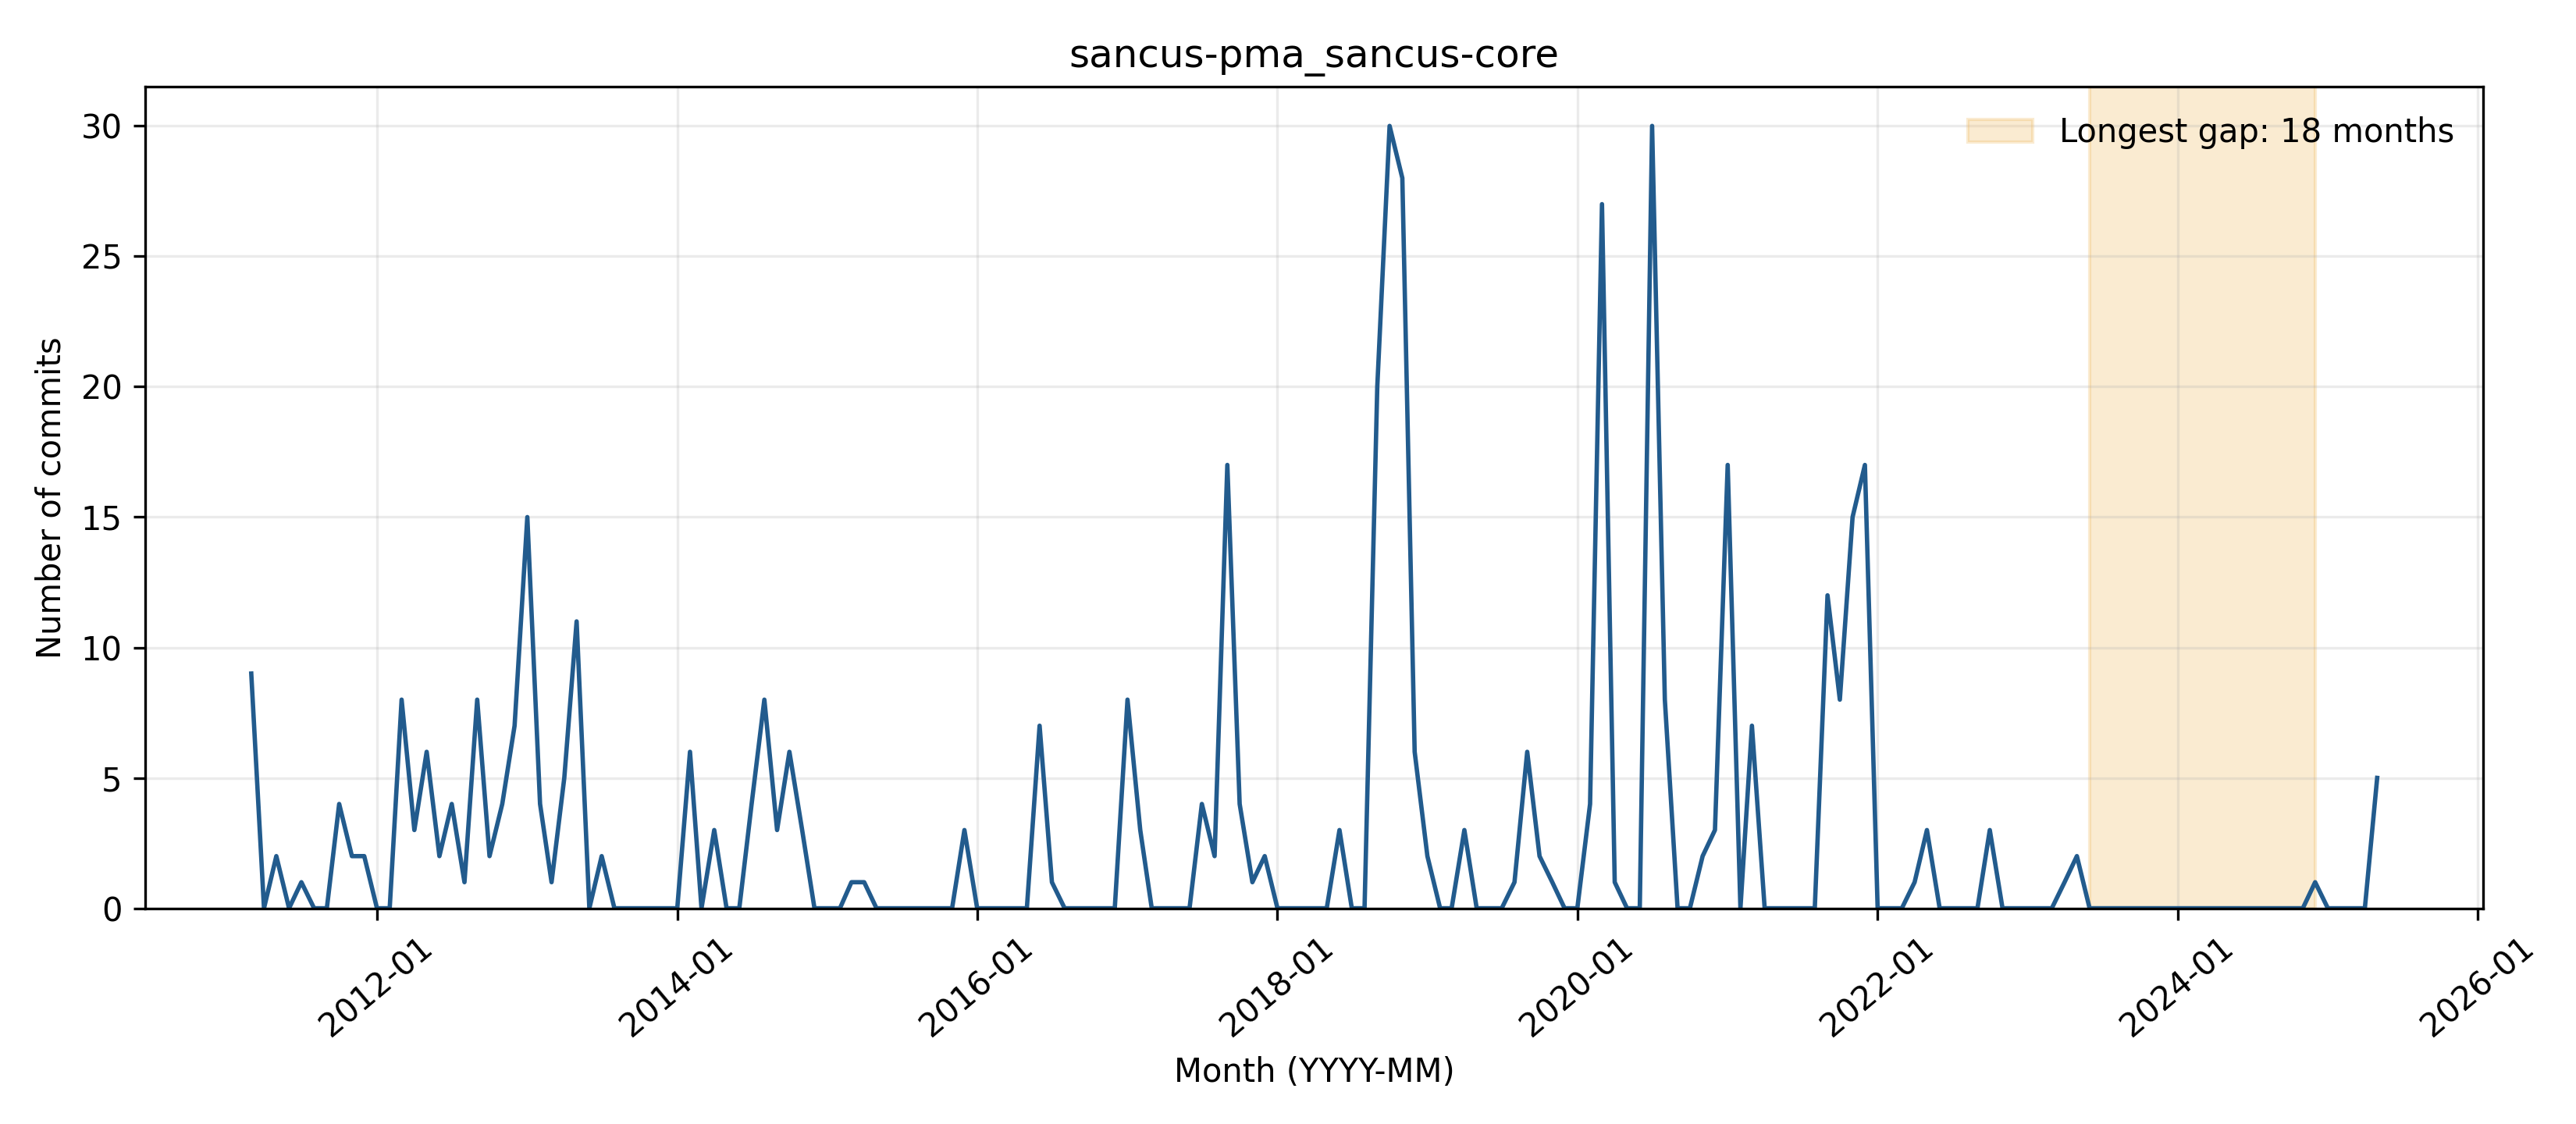

In [9]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_sancus-pma_sancus-core.png", width=900))

## shellphish_driller

**Overall pattern:** declining. **Gaps of at least three months:** 7. **Longest gap:** 2022-05 through 2025-02 (34 months).

Driller has the longest gap of the ten projects: 34 months, from May 2022 through February 2025. Activity had already dropped from hundreds of commits to occasional maintenance fixes. The gap ended with one March 2025 commit by Audrey Dutcher to support multiple angr versions, and Audrey had contributed before the gap too. That's evidence of a returning maintainer making one compatibility fix, not a full project revival. The single post-gap message only supports one theme, so I left the second as N/A.

**Commit themes:** Before: Bug fixes:Dependency updates; after: Dependency updates:N/A.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_shellphish_driller.md`.


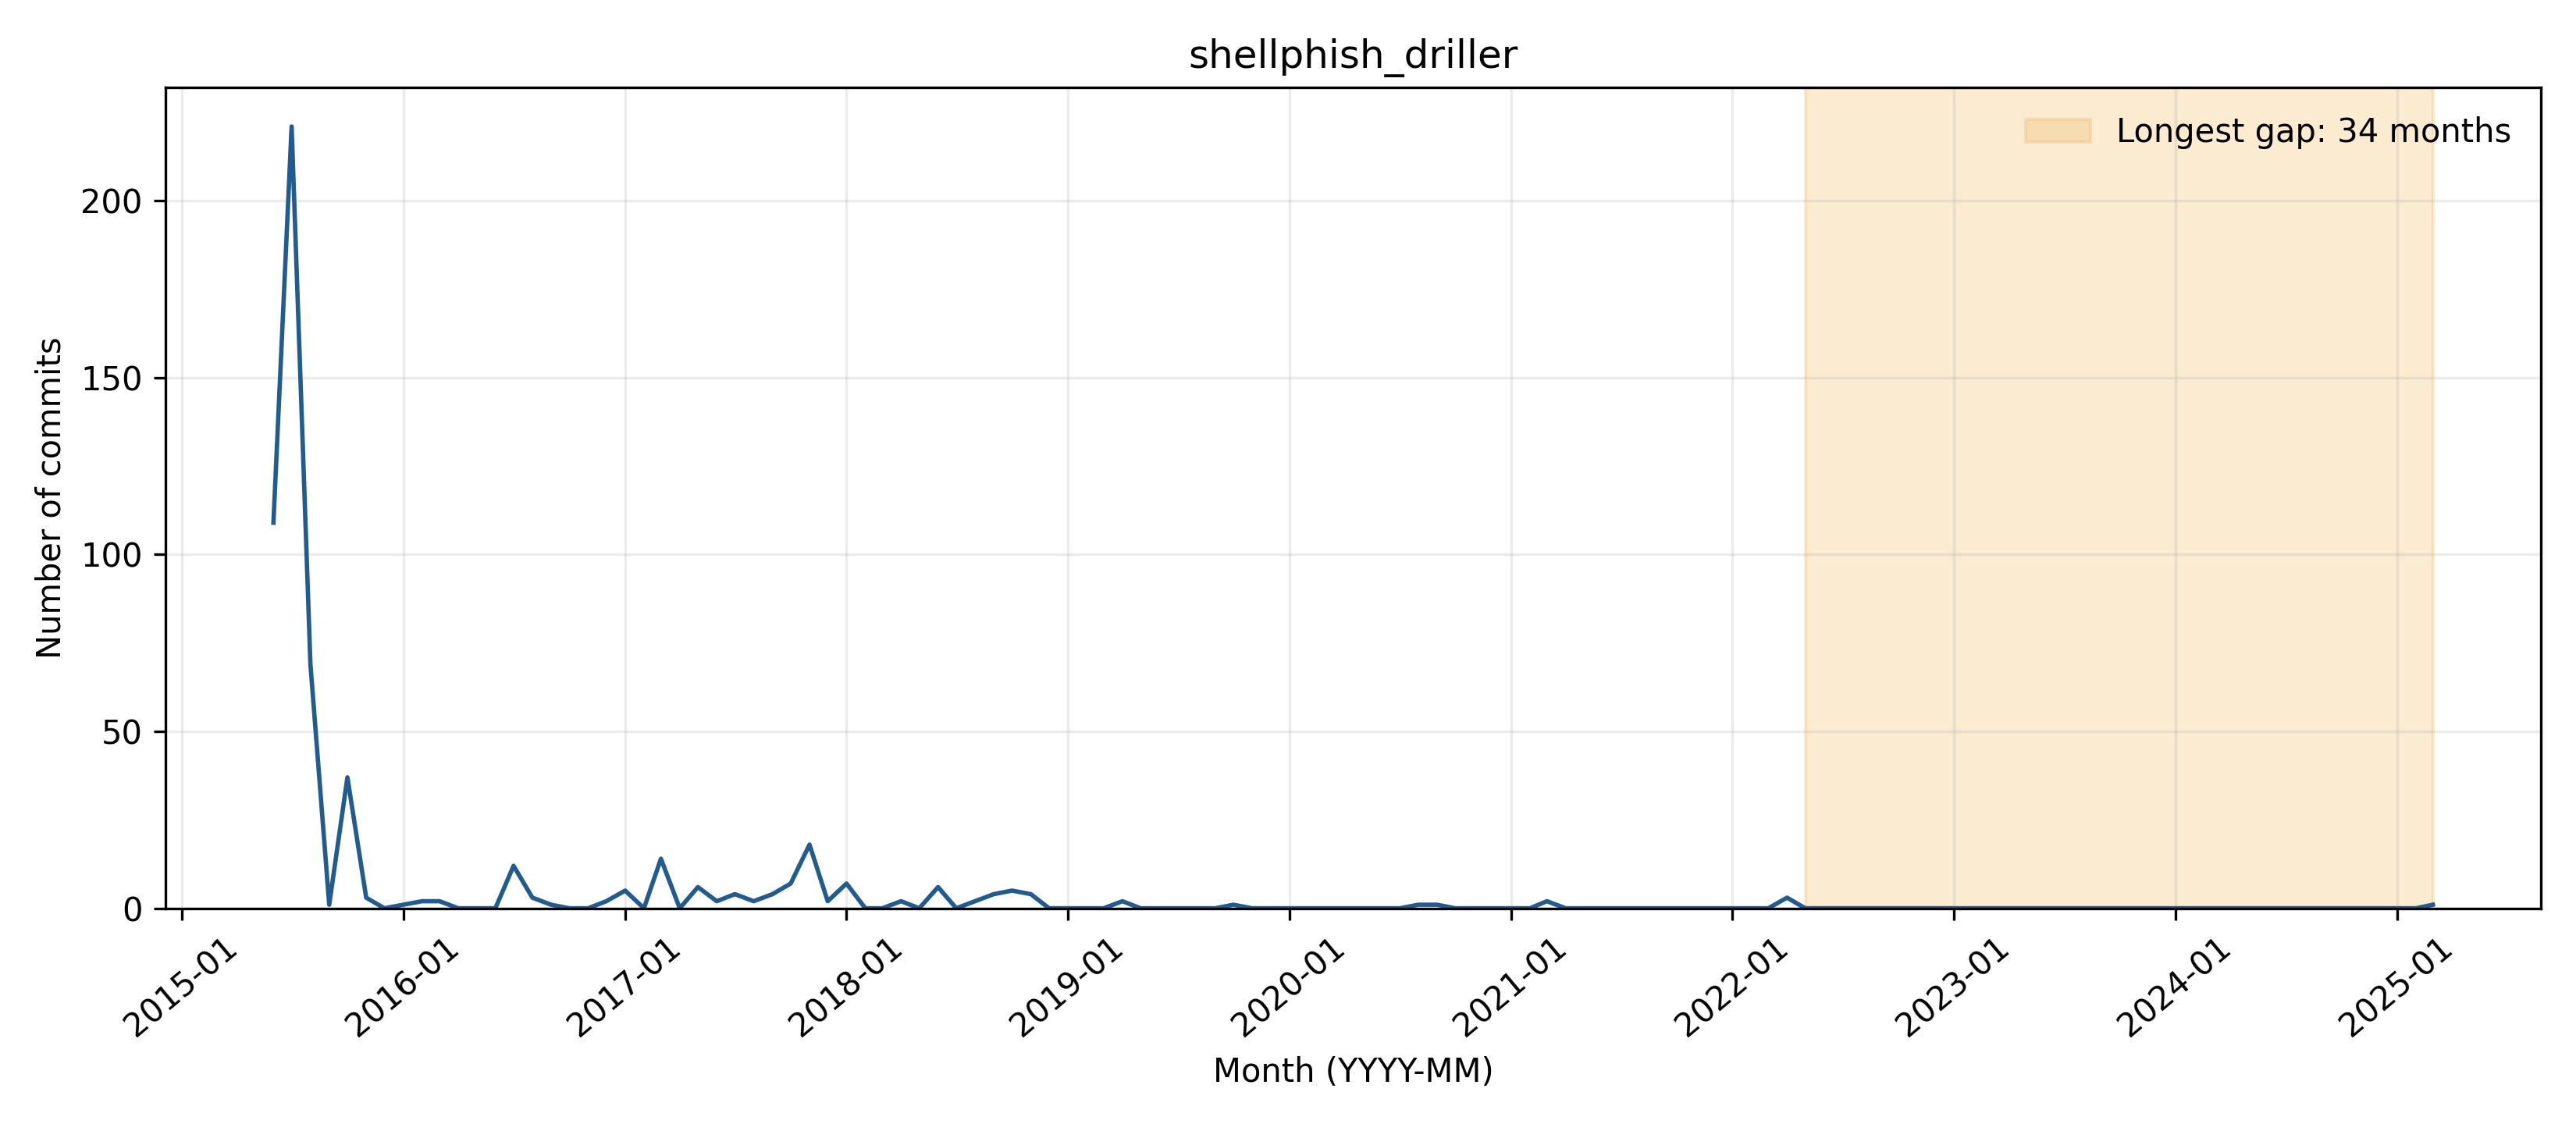

In [10]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_shellphish_driller.png", width=900))

## threeme3_qcx-ssb

**Overall pattern:** declining. **Gaps of at least three months:** 6. **Longest gap:** 2022-11 through 2023-07 (9 months).

QCX-SSB has a nine-month gap from November 2022 through July 2023, but the two commits that first follow it don't say much beyond editing usdx.ino. That makes the actual restart hard to interpret. Later changes, including the I2C fix in PR #86, show that someone was still maintaining the code from time to time. The repository has also moved to threeme3/usdx, and the latest default-branch commit has different author and committer dates, so I had to be careful comparing GitHub with the WoC timeline.

**Commit themes:** Before: Documentation updates:Bug fixes; after: Other:Bug fixes.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_threeme3_qcx-ssb.md`.


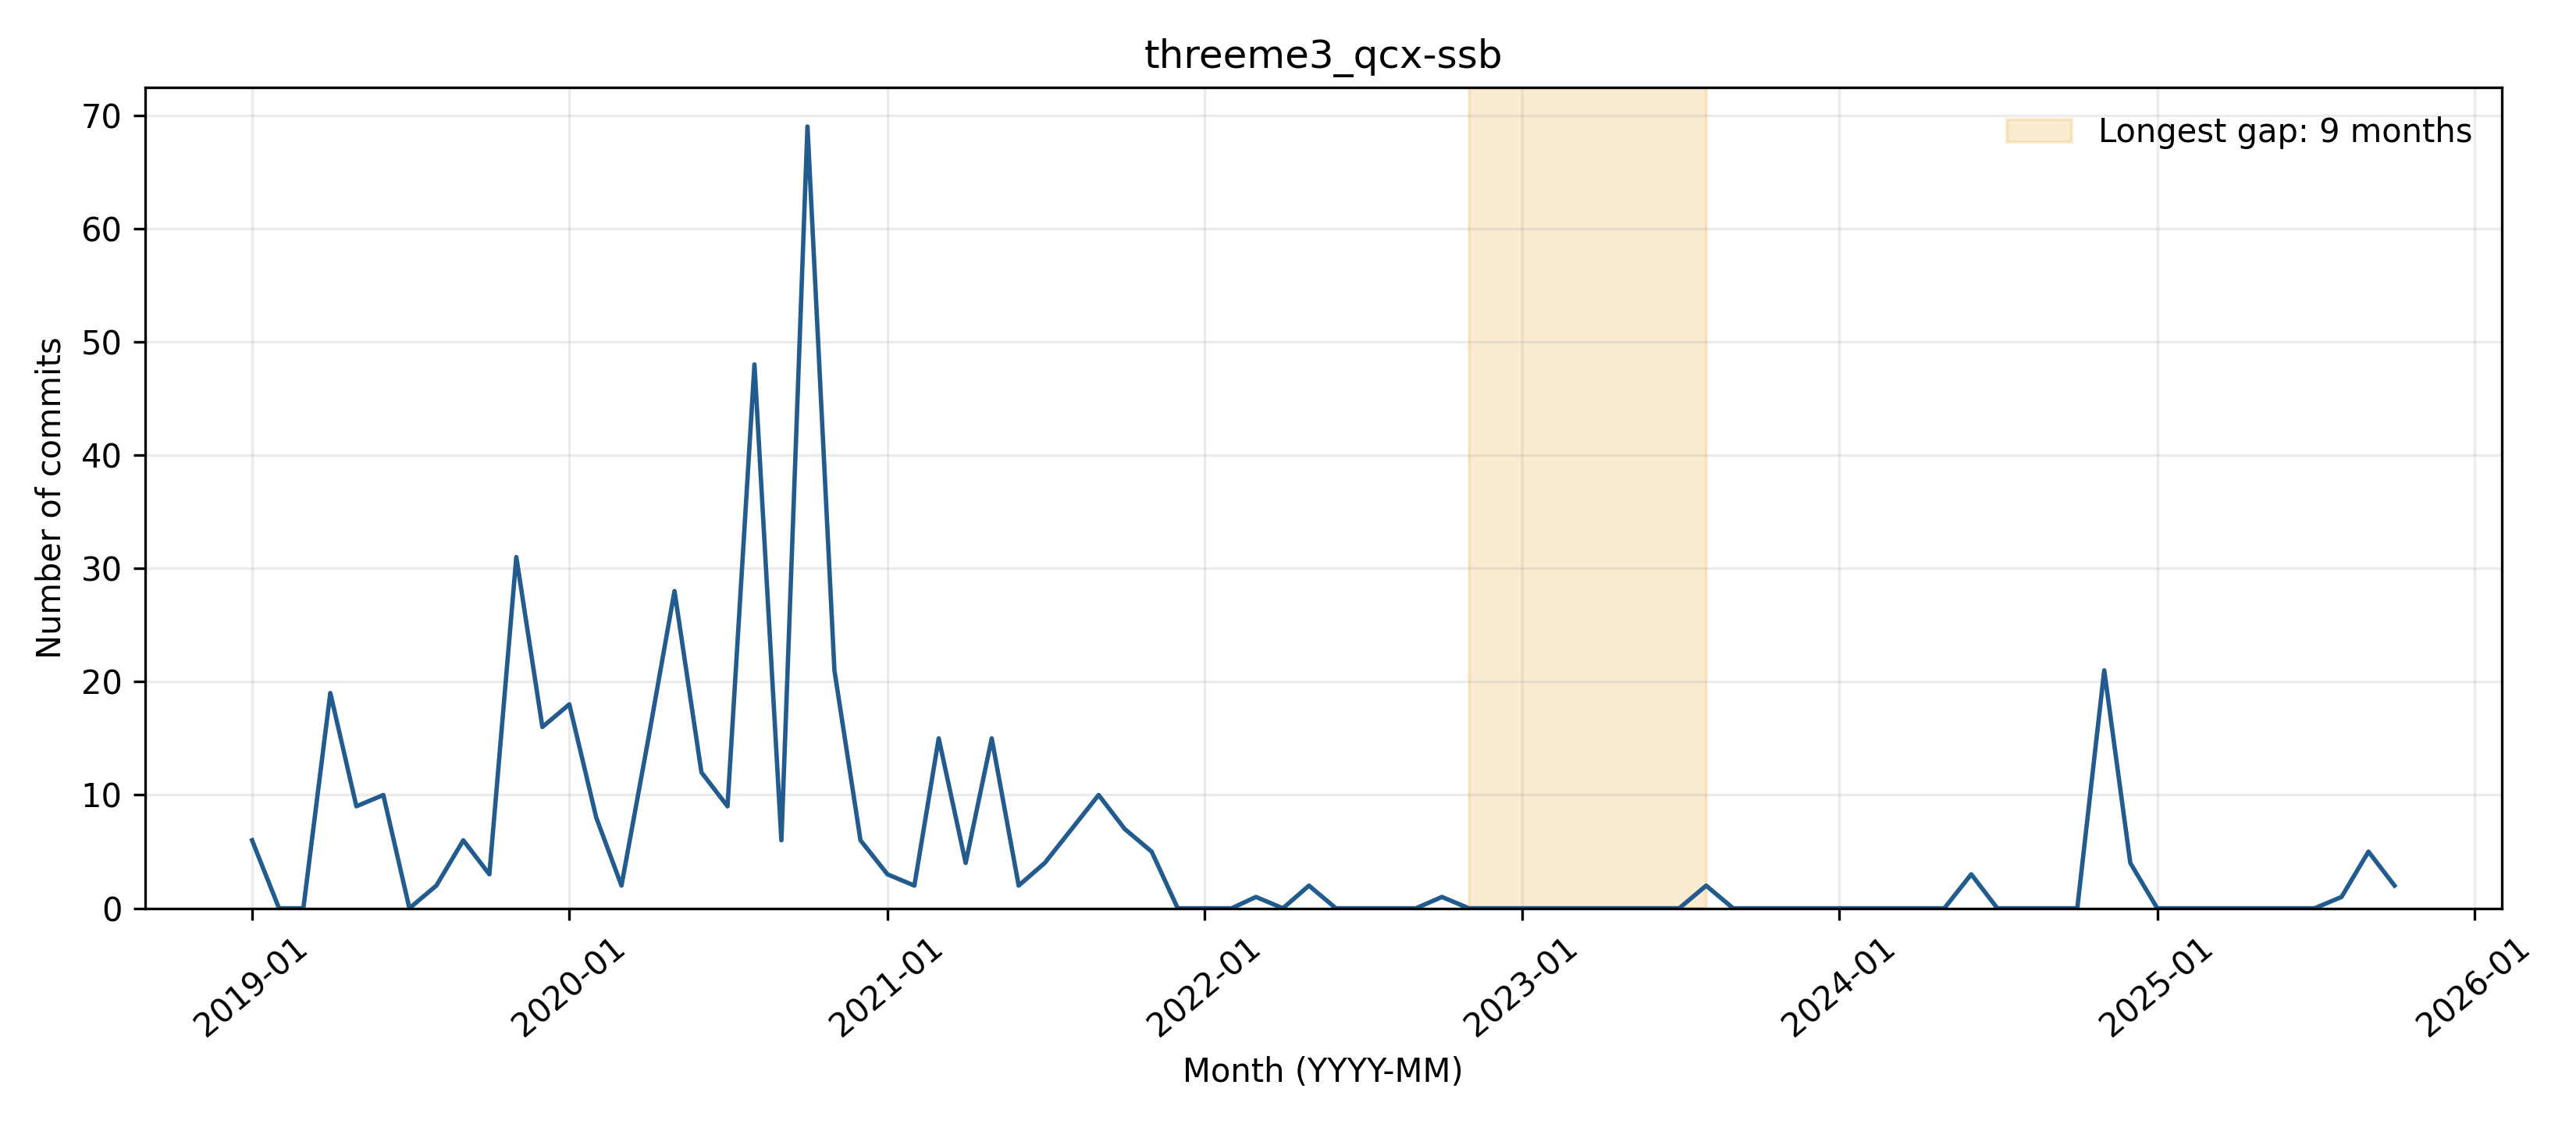

In [11]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_threeme3_qcx-ssb.png", width=900))

## vcflib_vcflib

**Overall pattern:** irregular. **Gaps of at least three months:** 3. **Longest gap:** 2021-06 through 2021-12 (7 months).

vcflib went seven months without commits in 2021, then returned in January 2022 with a man-page installation fix. GitHub PR #321 was merged, and later commits tackled dependencies and bugs, so there's good evidence that the work actually resumed. The graph then shows a large 2022 spike rather than a smooth trend, which is why I called it irregular. Pjotr Prins contributed on both sides of the gap, with Alexander Regueiro and others in the post-gap sample. I still couldn't find a clear reason the project paused in 2021.

**Commit themes:** Before: Documentation updates:Bug fixes; after: Bug fixes:Dependency updates.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_vcflib_vcflib.md`.


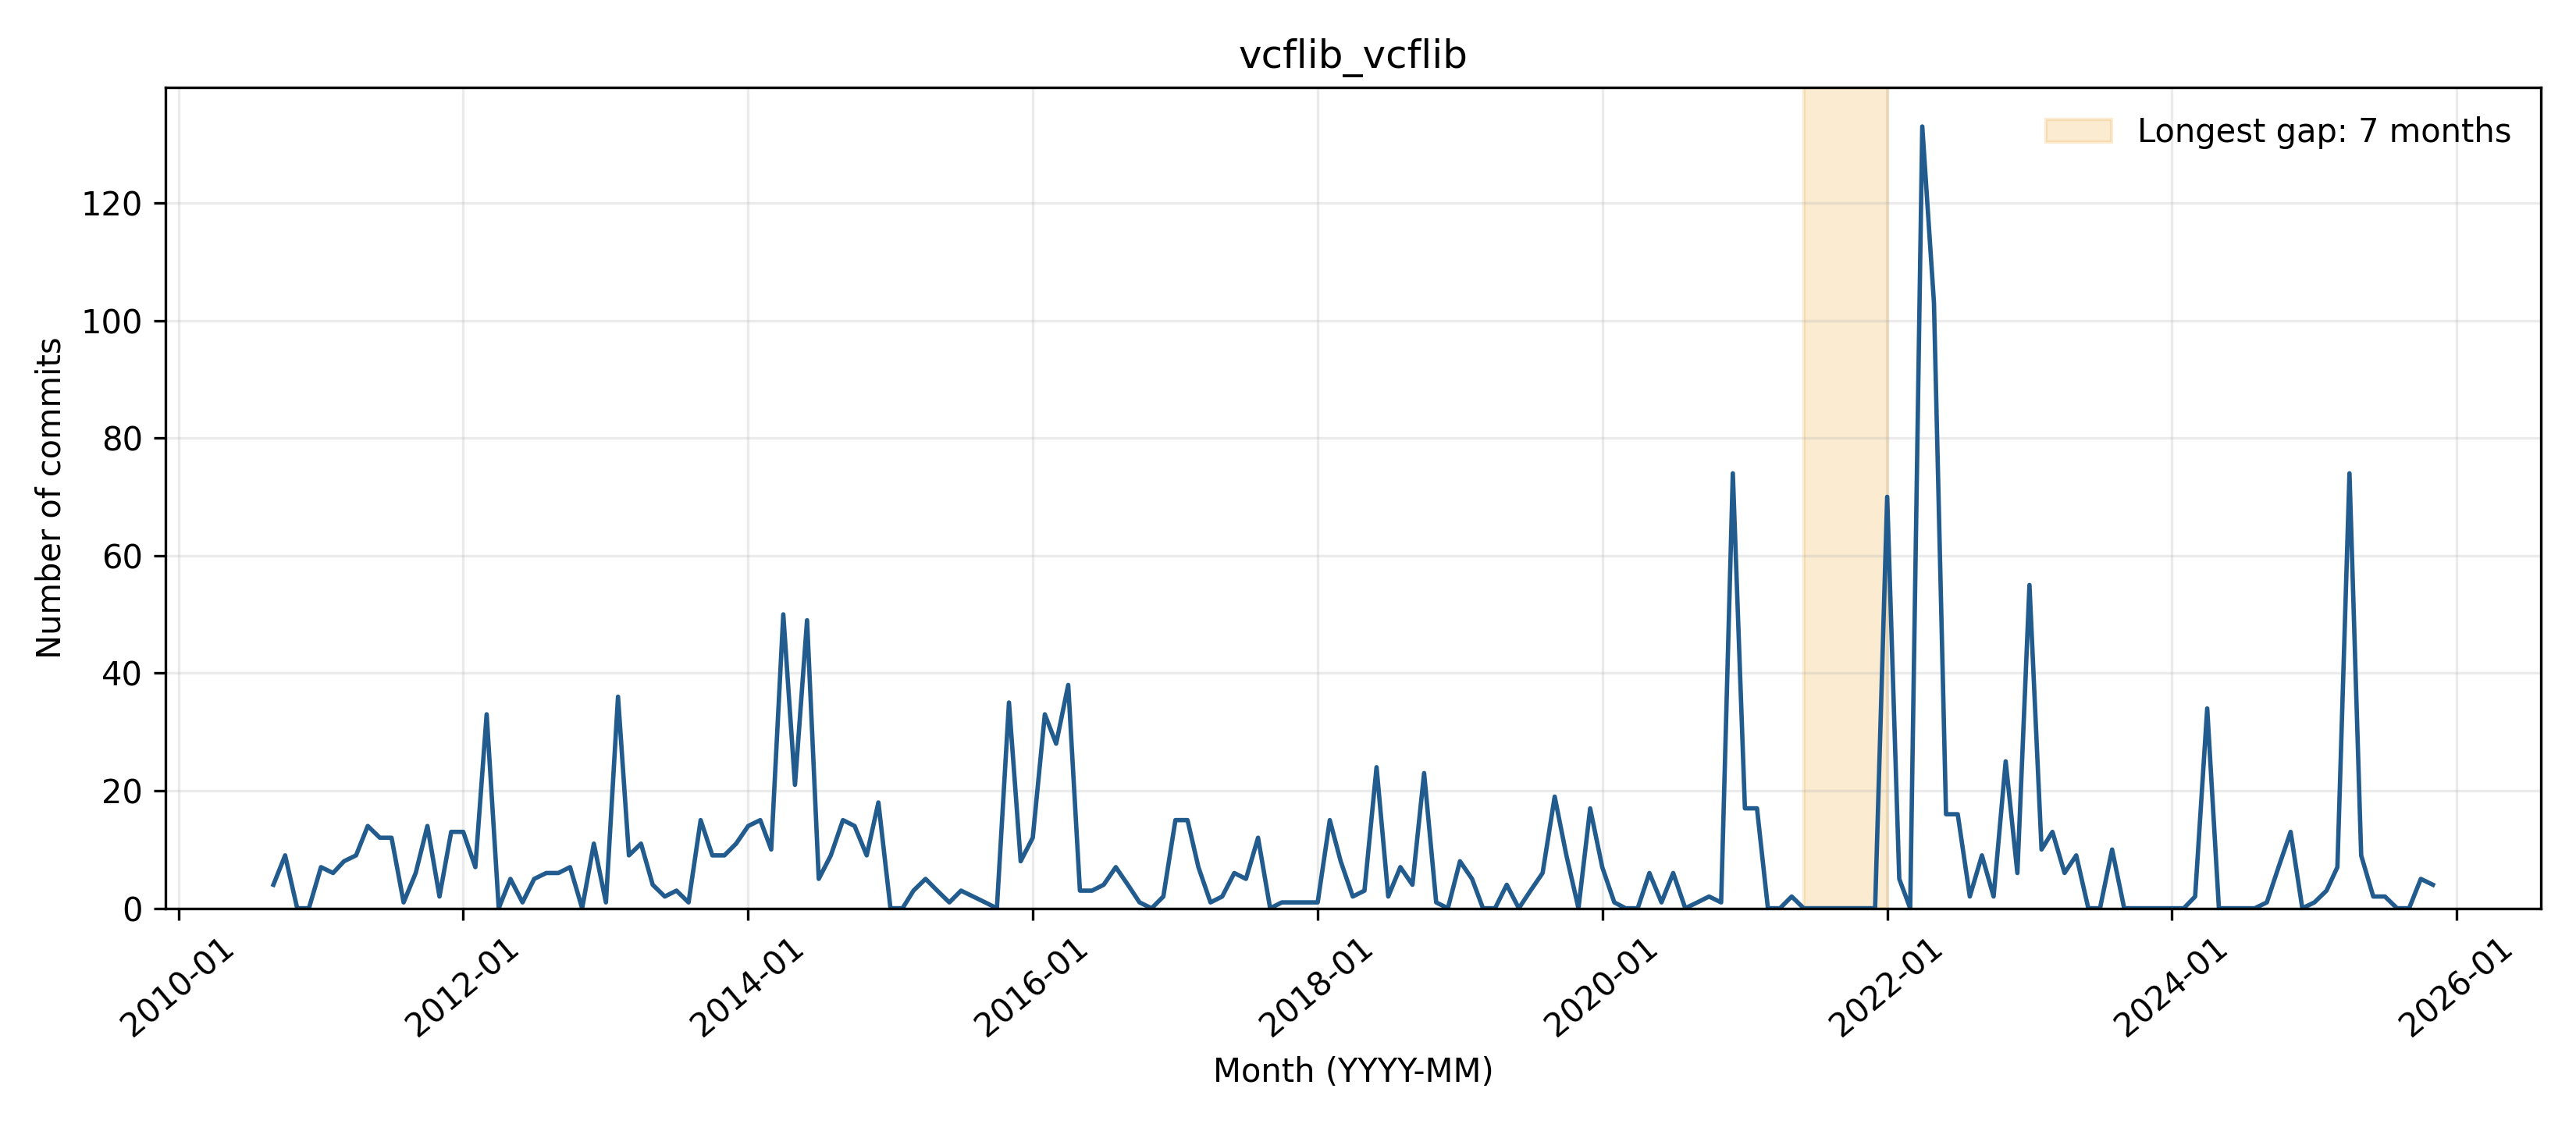

In [12]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_vcflib_vcflib.png", width=900))

## vinecopulib_rvinecopulib

**Overall pattern:** U-shaped. **Gaps of at least three months:** 4. **Longest gap:** 2021-02 through 2021-05 (4 months).

rvinecopulib starts with high activity, drops off around 2021–2023, and rises again in 2024–2025, so U-shaped was the closest overall description. Its longest gap lasted four months in early 2021. PR #235 helps explain the restart: the delayed merge brought in R 4.1 compatibility work, and fixes and documentation followed. Thomas Nagler and tnagler appear on both sides, suggesting continuity. I couldn't establish why the merge took that long or why activity paused in the first place.

**Commit themes:** Before: Bug fixes:Release; after: Bug fixes:Documentation updates.

The supporting commit samples and GitHub evidence are in `gwright30_reflection_vinecopulib_rvinecopulib.md`.


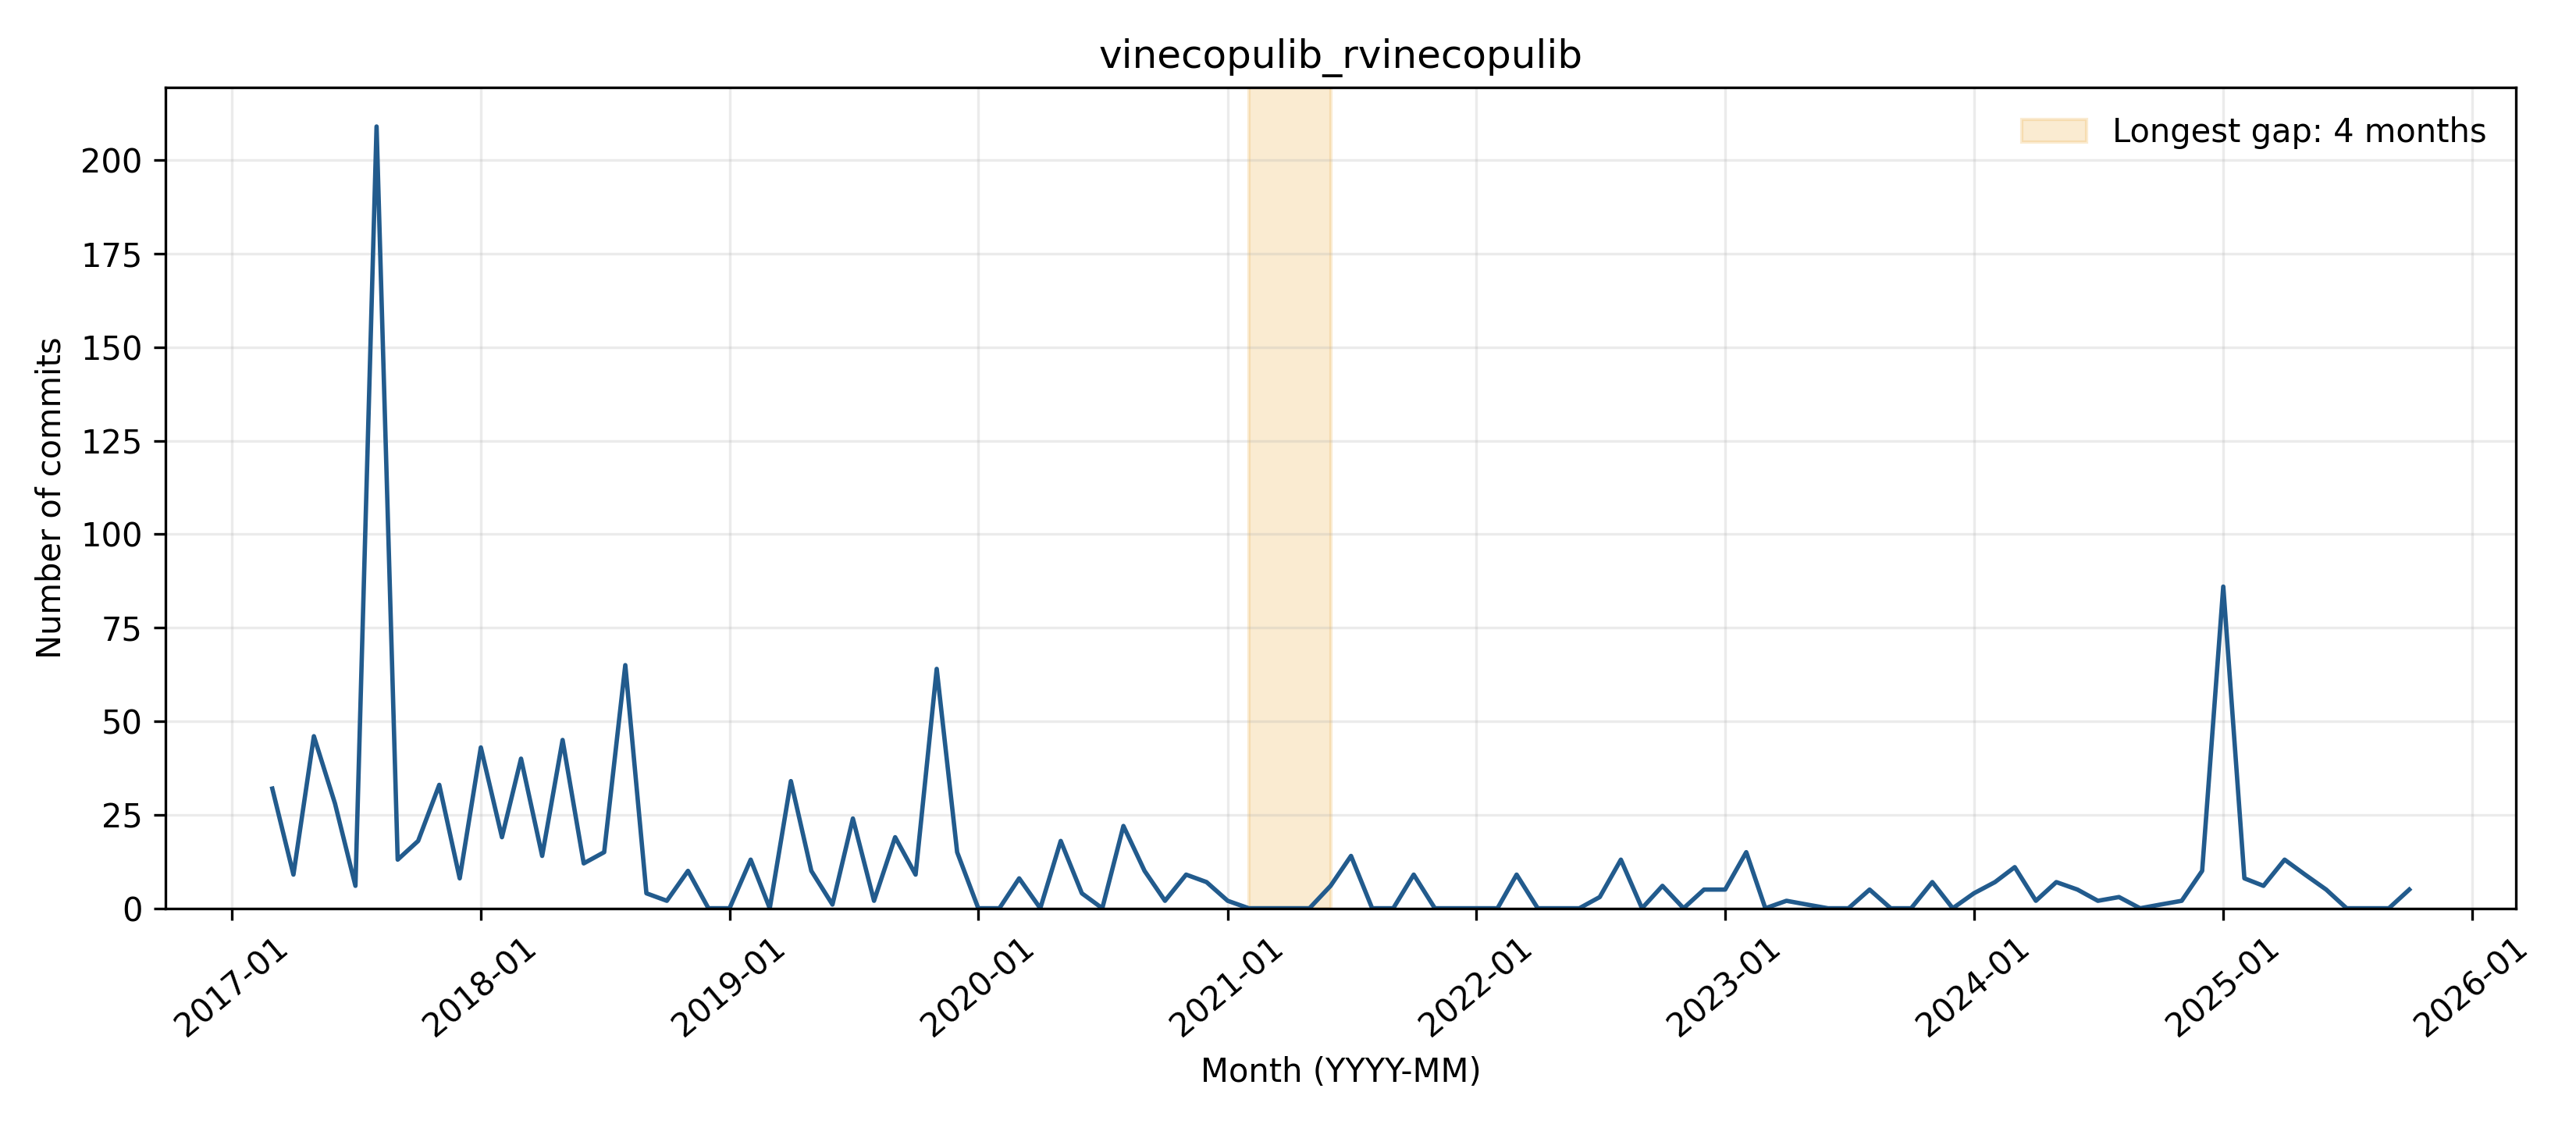

In [13]:
from IPython.display import Image, display
display(Image(filename="gwright30_timeseries_vinecopulib_rvinecopulib.png", width=900))